# BANK MARKETING: END-END SUPERVISED LEARNING PIPELINE

### **About**
A classification machine learning problem aimed at predicting whether bank client will subscribe to term deposit ('Yes') or not ('No') after being contacted during marketing campaign.
- **Term Deposit Subscription (Class 'Yes')**: Indicates successful marketing outcome, where client agrees to subscribe to the bank's long-term deposit product, which is a positive outcome for the bank.
- **No Term Deposit Subscription (Class 'No')**: Indicates an unsuccessful marketing outcome, where client does not subscribe to term deposit.

### **Aim**
To develop comprehensive supervised learning workflow for predicting bank marketing campaign success. Demonstration of complete machine learning lifecycle, from meticulous data understanding & preprocessing to training, rigorous evaluation & insightful interpretation of multiple classification models. The ultimate goal is to provide data-driven insights to optimize future marketing strategies & enhance campaign effectiveness.

### **Business Context**
- **Industry:** Banking & Financial Services.
- **Challenge:** Optimizing marketing campaign efficiency, reducing costs per acquisition & increasing conversion rate for term deposit subscriptions. Effective targeting of potential clients is crucial for maximizing Return On Investment (ROI).
- **Opportunity:** Predictive analytics can significantly improve success rate of marketing campaigns by identifying clients most likely subscribing to term deposit, allowing for more focused & personalized outreach.
- **Dataset:** Bank marketing campaign data (45211 customers × 17 features) including client demographics, financial details & past campaign outcomes.

### **Technical Objectives**

#### 1. **Data Quality & Preprocessing**
- **Identify Data Issues:** Detect and handle missing values, duplicates, and noisy/outlier data.
- **Attribute Typing:** Clearly explain the types of attributes (Nominal, Ordinal, Numeric - Discrete/Continuous).
- **Preprocessing Application:** Apply necessary preprocessing techniques such as handling missing values, encoding categorical variables, and feature scaling (standardization/min-max).
- **Dataset Splitting:** Divide the processed dataset into appropriate training and testing sets for model development and unbiased evaluation.
- **Justification:** Provide clear justifications for all data preprocessing decisions.

#### 2. **Model Training & Evaluation (Baselines)**
- **Baseline Model Training:** Train at least two baseline supervised models (e.g., Logistic Regression, Naive Bayes).
- **Comprehensive Evaluation:** Evaluate model performance using standard metrics: Confusion Matrix, Accuracy, Precision, Recall, F1-score, and ROC-AUC (where applicable).

#### 3. **Decision Tree Learning & Interpretation**
- **Decision Tree Training:** Train a Decision Tree Classifier.
- **Hyperparameter Tuning:** Experiment with key hyperparameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` to optimize performance.
- **Model Interpretation:** Analyze and interpret the trained Decision Tree model, focusing on feature importance and explaining at least two significant decision paths.

#### 4. **kNN (Lazy Learning)** (Aligns with Task E) 📏
- **kNN Classifier Training:** Train kNN classifiers with varying `k` values (e.g., 1, 3, 5, 7, 9).
- **Distance Metrics Exploration:** Experiment with different distance metrics (if feasible with the chosen library/implementation).
- **Conceptual Understanding:** Explain the critical role of feature scaling for kNN and how the choice of `k` affects the bias-variance trade-off.

#### 5. **Ensemble Learning & Comparison**
- **Ensemble Model Training:** Train at least two ensemble models (e.g., Random Forest, Gradient Boosting/XGBoost).
- **Performance Comparison:** Compare the performance of ensemble models against Decision Trees, kNN, and the baseline models using a comprehensive comparison table including Accuracy and F1-score.
- **Model Recommendation:** Identify the best-performing model and justify the choice based on evaluation metrics and business context.

#### 6. **Final Comparison, Recommendation & Risk Analysis**
- **Consolidated Comparison:** Create a final comparison table summarizing model Accuracy and F1-score for all trained models.
- **Best Model Justification:** Provide a rationale for which model performed best and explain the reasons.
- **Interpretability Analysis:** Discuss which model is most interpretable and why.
- **Deployment Risks:** Identify potential risks if the chosen model were to be deployed in a real-life scenario.

## 1. **Data Quality & Preprocessing**
Perform following:
  1. Identify missing values, duplicates, and noisy/outlier data.
  2. Explain the types of attributes:
      - Nominal
      - Ordinal
      - Numeric (Discrete/Continuous)
  3. Apply preprocessing:
      - Handling missing values
      - Encoding categorical variables
      - Feature scaling (standardization/min-max)
  - Split dataset into Train/Test.

### **1.1 Import Libraries & Mount Google drive**

In [53]:
import pandas as pd
import numpy as np
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import datasets
from io import StringIO
from sklearn.tree import export_graphviz
from sklearn import tree
from sklearn import metrics
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score,accuracy_score,recall_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import tree
from sklearn.model_selection import GridSearchCV

sns.set_style('darkgrid')
sns.set(font_scale = 1.1)
#########
# Configure libraries
# changing figure size
plt.rcParams['figure.figsize'] = (10, 10)

# ============================================================
# Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **Interpretation:** Importing essential libraries for data handling, manipulation, visualization, and machine learning models. Google Drive is mounted to allow notebook to access dataset files stored in Google Drive.

### **1.2 Define Input Directory & File Name**
Setting up path to access dataset file for easy & structured access.

In [54]:
# Input directory & files (as per your shell output)
INPUT_DIR = Path("/content/drive/MyDrive/2/ML/GradedAssignment/data")
FILENAME = INPUT_DIR/"bank_marketing_dataset.csv"
print("File:", FILENAME.name)

File: bank_marketing_dataset.csv


#### **Interpretation:** Input directory & filename are set-up programmatically for easy access to dataset, making code more portable/readable.

#### **1.3 HTML Style Adjustment for Tables**
Adjusting HTML style to ensure tables are left-aligned for better readability in notebook.

In [55]:
%%html
<style>
    table {float:left}
</style>

#### **Interpretation:** This HTML style adjustment ensures that tables are aligned to the left, which can improve the visual layout and readability of tables in the Jupyter environment.

### **1.4 Load Dataset into DataFrame**
Load `bank_marketing_dataset.csv` file into pandas data-frame & display its dimensions.

In [56]:
print("Reading files from:", INPUT_DIR)
df = pd.read_csv(FILENAME, sep=';')
print("Shapes:", FILENAME.name, df.shape)

Reading files from: /content/drive/MyDrive/2/ML/GradedAssignment/data
Shapes: bank_marketing_dataset.csv (45211, 17)


#### **Interpretation:** The dataset is loaded into Pandas data-frame, which is a fundamental data structure for data manipulation. Printing shape confirms the successful loading & provides an initial overview of dataset's dimensions (rows, columns).

### **1.5 Dataset Inspection**
Examine dataset structure, data types, missing values, duplicates & unique values to understand data quality & identify preprocessing needs.

**Overview:**
- **45211 clients** with **17 features** describe demographics, financial details & past campaign outcomes.
- Each row represents one customer with attributes such as age, job, marital status, and campaign-related information.
- **Target Variable:** y (renamed to deposit), whether client subscribed to a term deposit ('yes'/'no') (binary classification).
- **Record**: Each record represents an individual bank customer with attributes such as demographics, account details & previous campaign interactions. The target variable is deposit (originally y), which indicates whether a client has subscribed to a term deposit. This is a binary classification problem:
    *   1 (Yes) → Client is likely to subscribe to a term deposit
    *   0 (No) → Client is not likely to subscribe to a term deposit

**Description:**
- This dataset contains information about direct marketing campaigns, often requiring more than one contact to same client for predicting if the client will subscribe to term deposit.

**Feature Categories:**
- **Client Data:** age, job, marital, education, default, balance, housing, loan.
- **Last Contact Information:** contact, month, day, duration.
- **Other Attributes:** campaign, pdays, previous, poutcome.
- **Target Variable:** y (deposit).

**Features:**
1.  **age:** Age of the client (numeric).
2.  **job:** Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown').
3.  **marital:** Marital status (categorical: 'divorced', 'married', 'single', 'unknown').
4.  **education:** Education level (categorical: 'primary', 'secondary', 'tertiary', 'unknown').
5.  **default:** Has credit in default? (binary: 'no', 'yes').
6.  **balance:** Average yearly balance, in euros (numeric).
7.  **housing:** Has housing loan? (binary: 'no', 'yes').
8.  **loan:** Has personal loan? (binary: 'no', 'yes').
9.  **contact:** Contact communication type (categorical: 'cellular', 'telephone', 'unknown').
10. **day:** Last contact day of the month (numeric).
11. **month:** Last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec').
12. **duration:** Last contact duration, in seconds (numeric). <br>
*Note: Attribute highly affects target output (e.g. if duration=0, y='no'). Duration is not known ,before call is performed. Also, after end of call, y is obviously known. Input must be included for benchmark purposes & must be discarded for realistic predictive model.*
13. **campaign:** Number of contacts performed during this campaign, for particular client (numeric, includes last contact).
14. **pdays:** Number of days passed after client was last contacted from previous campaign (numeric; -1 means client was not previously contacted).
15. **previous:** Number of contacts performed before campaign and for particular client (numeric).
16. **poutcome:** Outcome of the previous marketing campaign (categorical: 'failure', 'other', 'success', 'unknown').
17. **y (deposit):** Has the client subscribed to a term deposit? (binary: 'no', 'yes').

#### **1.5.1 Display Dataset Dimensions**
Print number of rows & columns to confirm the dataset's scale.

In [57]:
# Prints dataset dimensions (rows and columns) to confirm successful loading and provide an initial
# understanding of dataset scale to validate data import and structure before analysis.
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 45211
Number of Columns: 17


#### **Interpretation:** Size of dataset, providing clear indication of how many records & features available for analysis, crucial for subsequent data handling & model building.

#### **1.5.2 Column Names**
Column names to understand feature set & identify potential target/ predictor variables.

In [58]:
# Displays all column names to understand feature scope and identify potential target
# and predictor variables, to map the raw schema for planning preprocessing strategies.
print("\n📊 Columns:")
print(df.columns.tolist())


📊 Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


#### **Interpretation:** List column names to understand available features in  dataset, prerequisite for any data manipulation, feature engineering or model development tasks.

#### **1.5.3 Top Records**
First few rows o DataFrame for quick visual inspection of data integrity & values.

In [59]:
# Displays first few records of dataset for quick inspection of sample values & column
# consistency, to visually confirm data integrity & detect anomalies early.
print("\n🧾 Read top records of DataFrame:")
df.head()


🧾 Read top records of DataFrame:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#### **Interpretation:** Viewing top records offers an immediate glimpse into  data's structure, variable types & sample values, to spot initial inconsistencies or unexpected formats.

#### **1.5.3  Bottom Records**
Last few rows of DataFrame to check for data completeness & any trailing issues.

In [60]:
# Displays the last few records to verify dataset completeness and check for trailing
# missing or corrupted entries, to ensure there are no truncation or import issues.
print("\n🧾 Reading bottom records of DataFrame:")
df.tail()


🧾 Reading bottom records of DataFrame:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


#### **Interpretation:** Bottom records complements head view by ensuring data consistency throughout DataFrame & identifying any truncation or import problems that might manifest at end of the file.

#### **1.5.4. DataFrame Summary**
Summary of DataFrame including data types, non-null counts & memory usage, to assess data quality.

In [61]:
# Provides a concise summary of dataset structure, column data types, non-null counts,
# and memory usage to assess data quality and inform imputation or transformation decisions.
print("\n🧾 Overall concise summary of DataFrame:")
df.info()


🧾 Overall concise summary of DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### **Interpretation:** Output informs decisions about data cleaning, type conversion, and memory management.

#### **1.5.5 Statistics for All Columns**
Descriptive statistics for both numerical & categorical columns to understand data distribution & variability.

In [62]:
# Generates descriptive statistics for all columns to summarize central tendency, dispersion & frequency
# to understand distribution & variability critical for outlier handling and feature scaling.
print("\n🧾 Statistics for all columns:")
df.describe(include='all')


🧾 Statistics for all columns:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


#### **Interpretation:** Descriptive statistics offer quantitative overview of each feature's distribution, to detect potential outliers, understand value ranges & guide decisions on normalization or standardization.

### **1.6 Types of Attributes**

#### **1.6.1 Group Columns by Data Types**
Group columns based on data types to facilitate type-specific preprocessing steps.

In [63]:
# Groups dataset columns by their data types and returns a mapping dictionary to
# facilitate type-specific feature engineering strategies (e.g., encoding vs scaling).
print('\nGroup columns by Data types')
g1 = df.columns.to_series().groupby(df.dtypes).groups
{k.name: v for k, v in g1.items()}


Group columns by Data types


{'int64': Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object'),
 'object': Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'poutcome', 'y'],
       dtype='object')}

#### **Interpretation:** Grouping columns by data type aids in ascertaining different data types available.
- **Nominal**: Categorical attributes whose values represent categories without any inherent order/ ranking.
  - job (e.g., 'management', 'technician', 'blue-collar')
  - marital (e.g., 'married', 'single', 'divorced')
  - default (binary: 'no', 'yes')
  - housing (binary: 'yes', 'no')
  - loan (binary: 'yes', 'no')
  - contact (e.g., 'unknown', 'cellular', 'telephone')
month (e.g., 'may', 'jun', 'jul' - often treated as nominal even though there's a cyclical order)
  - poutcome (e.g., 'unknown', 'failure', 'success')
y (deposit) (binary target variable: 'no', 'yes')

- **Ordinal**: Categorical attributes whose values have meaningful order or ranking but intervals between ranks are not necessarily uniform/ measurable.  
  - education (e.g., 'primary', 'secondary', 'tertiary', 'unknown' - implying a hierarchy)

- **Numeric**: Attributes have values which are numbers and can be subject to arithmetic operations, which can be further divided into below categories.
  - **Discrete Numeric**: Can only take on finite or countably infinite number of values, often integers which typically result from counting.
    - age
    - day
    - campaign
    - pdays (with -1 indicating no prior contact)
    - previous
  - **Continuous Numeric**: Can take on any value within given range, often involving decimals/ fractions which typically result from measurement.
    - balance
    - duration

#### **1.6.2 Numerical Attributes Distribution**

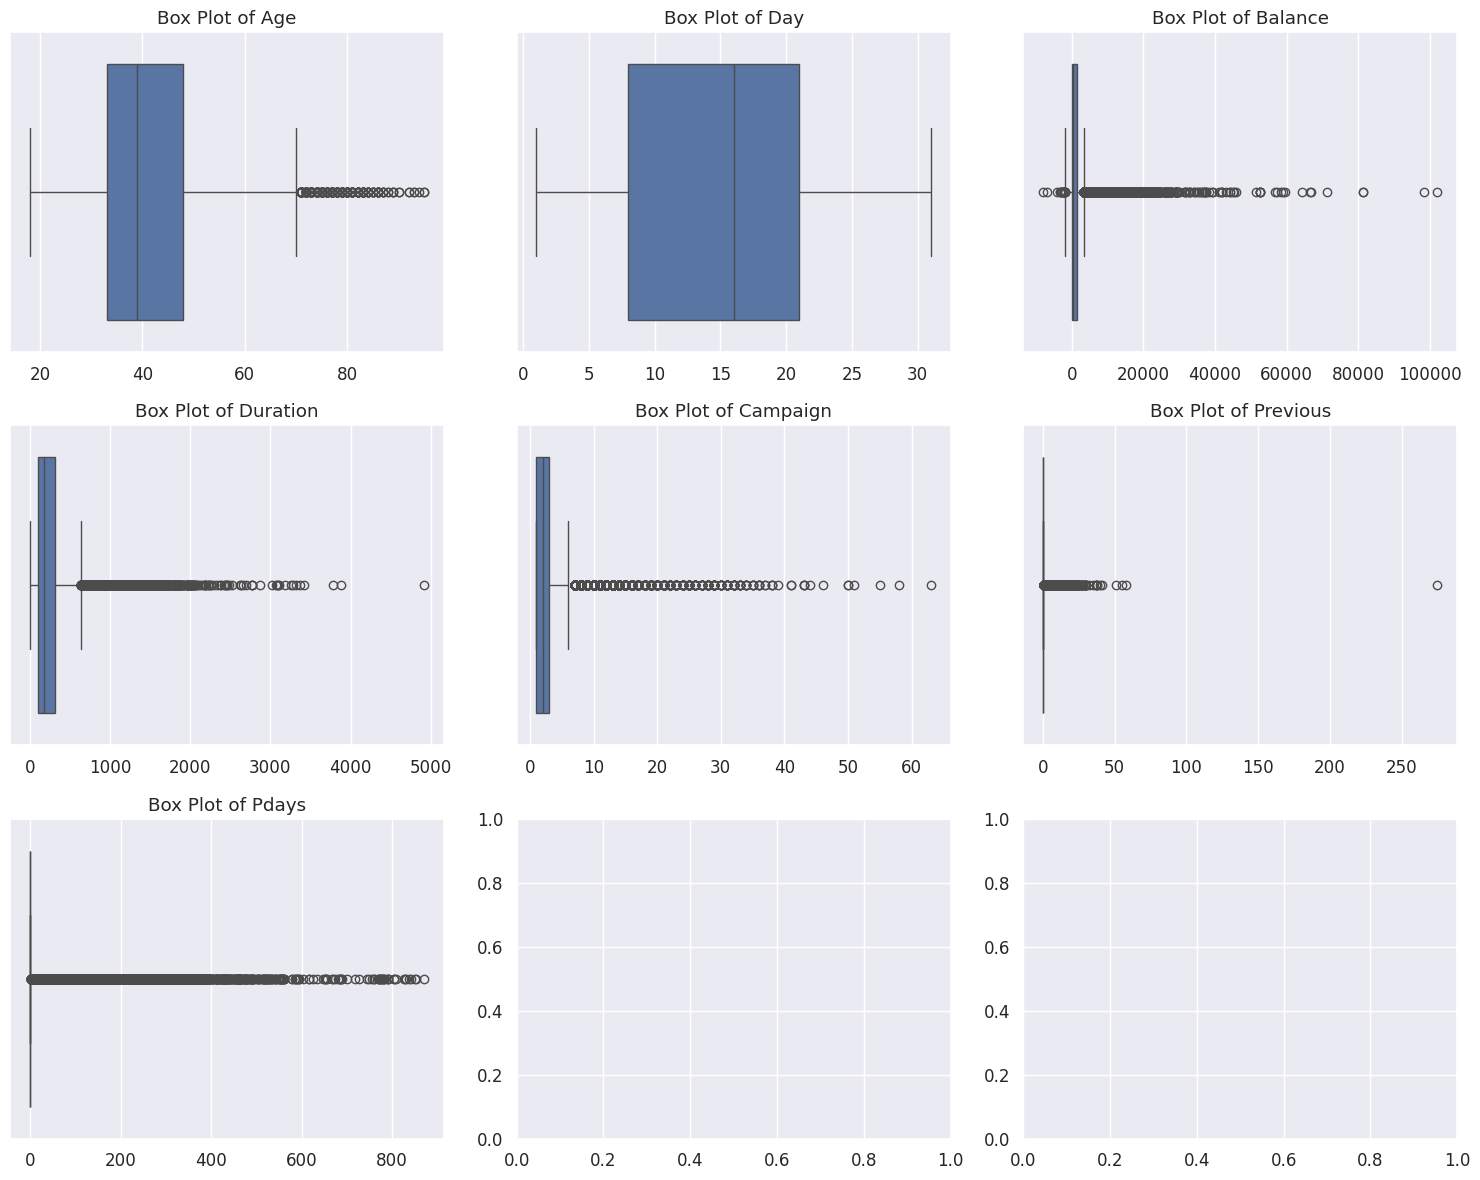

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical attributes to plot
num_attributes = ['age', 'day', 'balance', 'duration', 'campaign', 'previous', 'pdays']

# Determine grid size for subplots
n_plots = len(num_attributes)
n_cols = 3  # You can adjust this for desired layout
n_rows = (n_plots + n_cols - 1) // n_cols  # Calculate rows needed

# Create a figure and a set of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Loop through attributes and plot each boxplot
for i, attribute in enumerate(num_attributes):
    if i < n_plots:
        sns.boxplot(x=df[attribute], ax=axes[i])
        axes[i].set_title(f'Box Plot of {attribute.capitalize()}')
        axes[i].set_xlabel('') # Hide x-label as title is sufficient
    else:
        fig.delaxes(axes[i]) # Hide empty subplots if any

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()


**Interpretation:**
These box plots provide a visual summary of the distribution characteristics for each numerical attribute:

*   **Age**: The median age is approximately 40, with the bulk of customers falling between 30 and 50 years old, indicating a mature customer base.
*   **Day**: The distribution of contact days throughout the month appears relatively even, without significant clustering on specific days.
*   **Balance**: This attribute shows a wide spread of values. The median balance is low, suggesting that most customers have smaller account balances, while a few customers possess significantly higher balances.
*   **Duration**: The duration of the last contact call is heavily skewed, with a majority of calls being very short.
*   **Campaign**: Most customers were contacted a small number of times (median 1-2), with a declining frequency for higher contact counts.
*   **Previous**: The majority of customers had very few or no prior contacts, indicating that for many, this was their first interaction or a very early one.
*   **Pdays**: This feature is predominantly represented by '-1', signifying that most clients were not previously contacted. For those who were, the values show the elapsed days since the last contact.

#### **1.6.3 Mean of Numerical Attributes for Output Variable (y)**

In [65]:
df.pivot_table(["age", "day", "balance", "duration", "campaign", "previous", "pdays"], ["y"], aggfunc = "mean")

,age,balance,campaign,day,duration,pdays,previous
y,,,,,,,
no,40.838986,1303.714969,2.846350,15.892290,221.182806,36.421372,0.502154
yes,41.670070,1804.267915,2.141047,15.158253,537.294574,68.702968,1.170354


#### **Interpretation**
- age: Customers who subscribed (yes) have slightly higher average age (41.67) compared to those who did not (40.84), suggesting that slightly older clients might be marginally more inclined to subscribe.

- balance: Subscribers ('yes') have significantly higher average balance (1804.27) than non-subscribers ('no') (1303.71), which indicates that clients with higher account balances are more likely to subscribe for term deposit.

- campaign: Customers who subscribed ('yes') had lower average number of contacts during current campaign (2.14) compared to non-subscribers ('no') (2.85). This could imply that fewer, more targeted contacts might be more effective or that over-contacting can lead to 'no'.

- day: The average day of month for last contact is slightly lower for subscribers ('yes') (15.16) than for non-subscribers ('no') (15.89). This might suggest contacts earlier in the month are marginally more successful.

- duration: The average duration of last contact call is considerably longer for subscribers ('yes') (537.29 seconds) than for non-subscribers ('no') (221.18 seconds), which suggests that longer, more engaging conversations are crucial for successful term deposit subscriptions.

- pdays: Subscribers ('yes') have much higher average pdays value (68.70) than non-subscribers ('no') (36.42). As pdays represent number of days passed after the client was last contacted from previous campaign (with -1 for no prior contact), a higher positive value for pdays among subscribers suggests that customers who were contacted longer time ago (or successfully contacted in a previous campaign, leading to non -1 pdays) are more likely to subscribe.

- previous: Subscribers ('yes') had higher average number of contacts performed before this campaign (1.17) compared to non-subscribers ('no') (0.50), which implies clients with history of engagement or multiple previous interactions are more likely to subscribe for term deposit.

#### **1.6.4 Categorical Attributes**

In [66]:
categorical_attributes = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# unique values in categorical attributes
value_counts = df[categorical_attributes].nunique()
print("Value Counts of Categorical Attributes:")
print(value_counts)

Value Counts of Categorical Attributes:
job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
dtype: int64


#### **Interpretation**: Determine count of distinct categories within each categorical attribute, aiding in understanding data diversity & informing encoding strategies.

#### **1.6.5 Unique values per Categorical attribute**

In [67]:
print('Unique values per categorical attribute:')
for col in categorical_attributes:
    print(f"\n{col.capitalize()}: {df[col].unique().tolist()}")

Unique values per categorical attribute:

Job: ['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']

Marital: ['married', 'single', 'divorced']

Education: ['tertiary', 'secondary', 'unknown', 'primary']

Default: ['no', 'yes']

Housing: ['yes', 'no']

Loan: ['no', 'yes']

Contact: ['unknown', 'cellular', 'telephone']

Month: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr', 'sep']

Poutcome: ['unknown', 'failure', 'other', 'success']


#### **Interpretation**: Display all individual unique values for each categorical attribute, for reviewing data consistency & identifying 'unknown' entries.

#### **1.6.6 Categorical Attribute Count Plots**

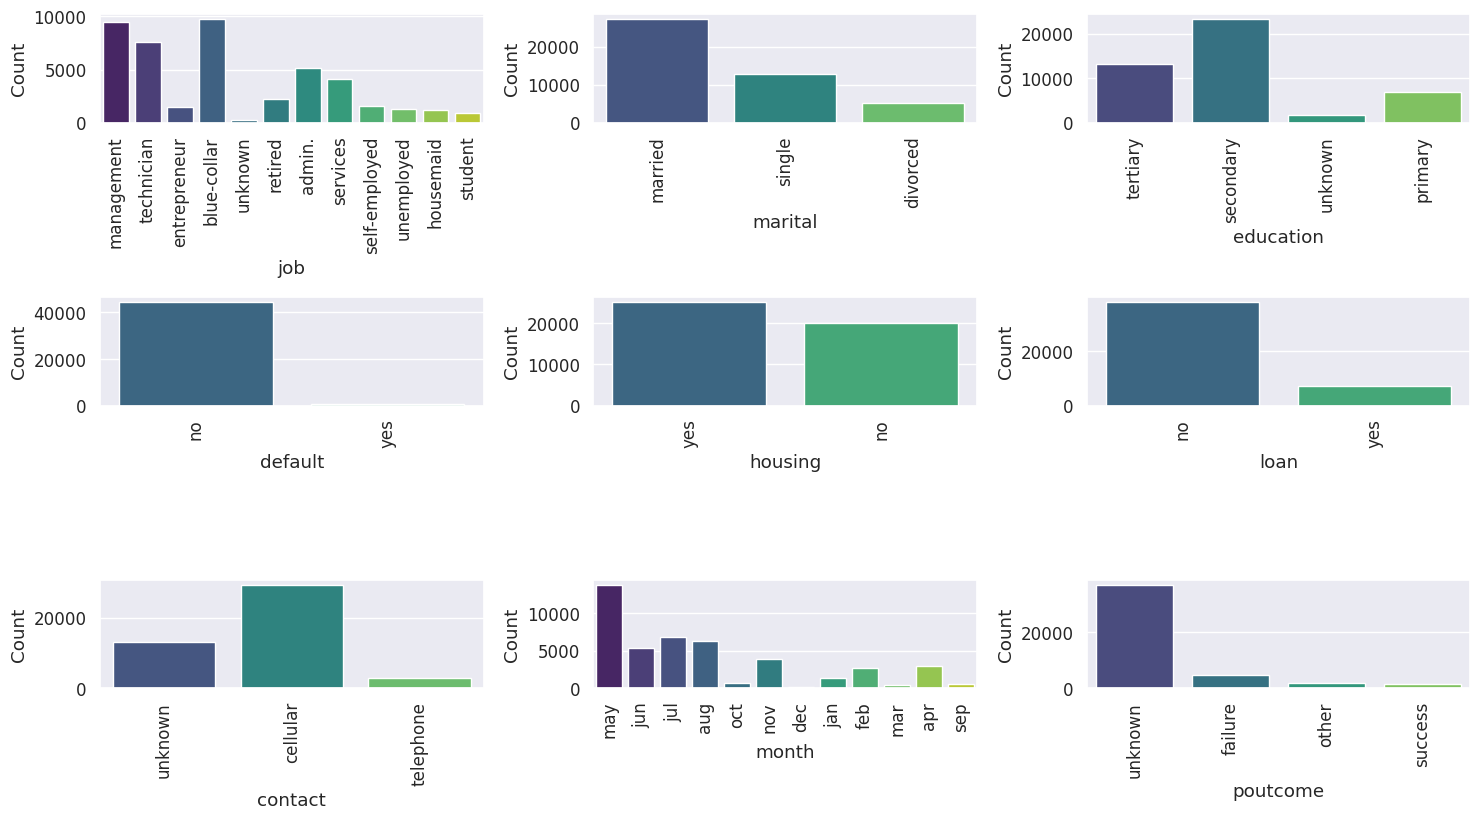

In [68]:
# Check if "count" is in the list of categorical attributes
if "count" in categorical_attributes:
    categorical_attributes.remove("count")

# Create a DataFrame from the categorical attributes
categorical_df = pd.DataFrame(df[categorical_attributes])

# Set the plot size
plt.figure(figsize=(15, 10))

# Loop through each categorical attribute and create count plots
for i, col in enumerate(categorical_df.columns):
    plt.subplot(4, 3, i+1)  # Adjust the subplot layout as per your number of attributes
    sns.countplot(x=col, data=categorical_df, palette='viridis')
    plt.xticks(rotation='vertical')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()  # Adjust the spacing between subplots if necessary
plt.show()

**Interpretation:**
Count plots provide insights into distribution of each category within dataset.
*   **Job**: Categories such as 'blue-collar' & 'management' are highly represented.
*   **Marital Status**: Predominantly 'married'.
*   **Education**: Largely 'secondary' & 'tertiary'.
*   **Default**: Most customers do not have 'default'.
*   **Loan**: Most customers do not have 'loan', but 'housing' loans are common.
*   **Contact Method**: 'Cellular' is most frequent 'contact' method.
*   **Campaign Month**: 'May' is most active 'month' for campaigns.
*   **Previous Outcome ('poutcome')**: 'Unknown' is most common prior campaign outcome, suggesting many clients were not previously contacted or outcome not recorded.

These distributions are crucial for understanding customer demographics & campaign history.

#### **1.6.7 Subscription Ratios for Categorical Attributes**

In [69]:
def explore_categorical_variables(data, categorical_attributes):
    # Create a DataFrame with the categorical attributes
    categorical_df = data[categorical_attributes]

    # Compute the ratio of subscription for each category
    for col in categorical_attributes:
        category_counts = data[col].value_counts()
        category_subscription_counts = data.loc[data['y'] == 'yes', col].value_counts()
        ratio = category_subscription_counts / category_counts
        print(f"\nSubscription ratio for {col}:")
        print(ratio)

In [70]:
explore_categorical_variables(df, categorical_attributes)


Subscription ratio for job:
job
admin.           0.122027
blue-collar      0.072750
entrepreneur     0.082717
housemaid        0.087903
management       0.137556
retired          0.227915
self-employed    0.118429
services         0.088830
student          0.286780
technician       0.110570
unemployed       0.155027
unknown          0.118056
Name: count, dtype: float64

Subscription ratio for marital:
marital
married     0.101235
single      0.149492
divorced    0.119455
Name: count, dtype: float64

Subscription ratio for education:
education
secondary    0.105594
tertiary     0.150064
primary      0.086265
unknown      0.135703
Name: count, dtype: float64

Subscription ratio for default:
default
no     0.117961
yes    0.063804
Name: count, dtype: float64

Subscription ratio for housing:
housing
no     0.167024
yes    0.077000
Name: count, dtype: float64

Subscription ratio for loan:
loan
no     0.126557
yes    0.066814
Name: count, dtype: float64

Subscription ratio for contact:
cont

**Interpretation**

  - **Subscription Ratio of Clients to Total Clients in Job Categories:**
     *   `student` (ratio=0.286)
     *   `retired` (ratio=0.227)
     *   `unemployed` (ratio=0.155)

  - **Marital Status:**: While majority of clients are married, clients who are `single` have highest subscription rate.

  - **Education:**   Clients with `tertiary` & `unknown` education backgrounds, show highest subscription rates.

  - **Housing Loan:**   Clients with `no housing loan` are more willing to subscribe for product.

  - **Personal Loan:**   Clients with `no personal loans` are more willing to subscribe for product.

  - **Contact Method:**   Clients contacted by `cellular` phone are more willing to subscribe to the product.

  - **Campaign Month:**
       *   `May`, `July`, and `August` are the top 3 months for client contact (from bar plot).
       *   `March`, `December`, and `September` have the highest subscription rates (from quantitative table).

  - **Previous Outcome (poutcome):**`success` and `other` categories show the highest subscription rates.

#### **1.6.8 Mode of Education for Each Job Title**

In [71]:
# mode of education for each job title
dictionary = {}
for job in df['job'].unique():
  accounts_with_job = df[df['job']==job]
  mode_job = accounts_with_job['education'].mode()[0]
  dictionary[job] = mode_job
print(dictionary)

{'management': 'tertiary', 'technician': 'secondary', 'entrepreneur': 'tertiary', 'blue-collar': 'secondary', 'unknown': 'unknown', 'retired': 'secondary', 'admin.': 'secondary', 'services': 'secondary', 'self-employed': 'tertiary', 'unemployed': 'secondary', 'housemaid': 'primary', 'student': 'secondary'}


#### **Interpretation**: Dictionary displays most frequent education level (mode) for each job category, for understanding typical educational backgrounds within different professions & potentially for imputing missing 'education' values based on 'job'.

#### **1.6.9 Heatmap of Numerical Feature Correlations**

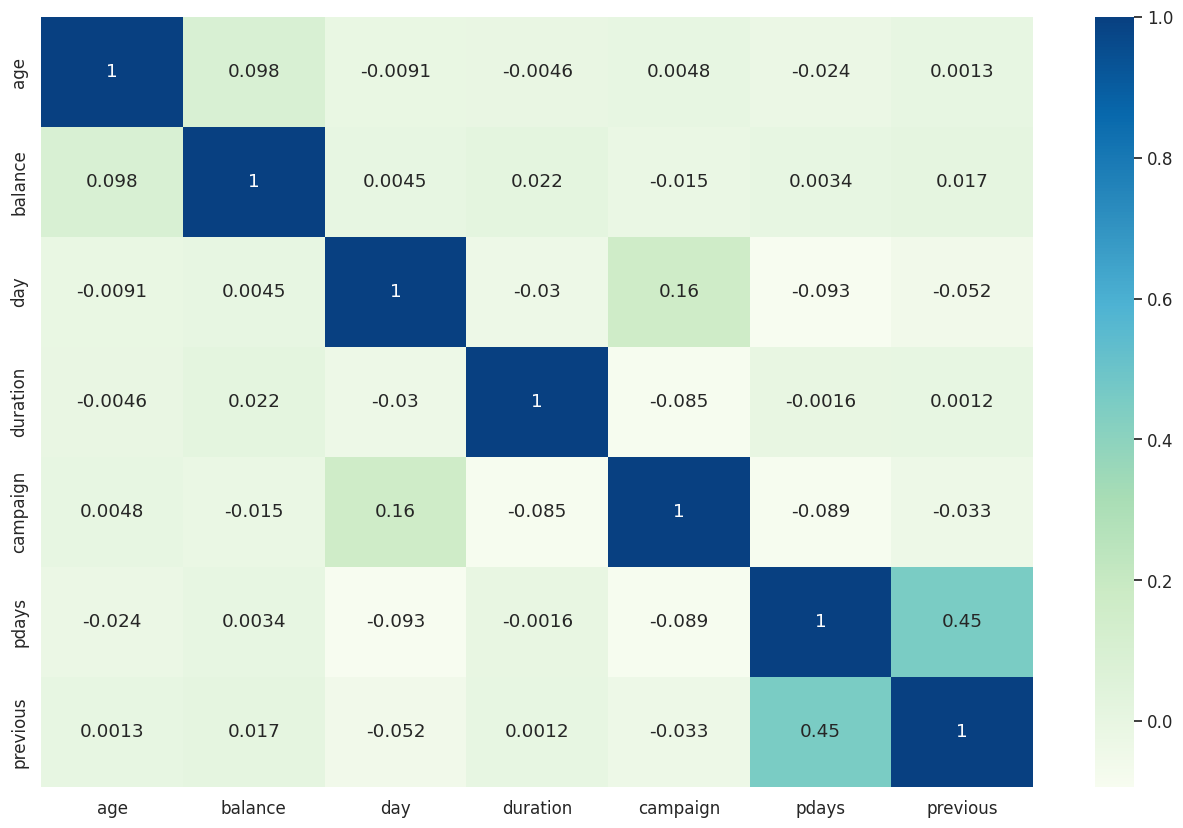

In [72]:
plt.figure(figsize=(16,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(method='pearson'), annot=True, cmap="GnBu")
plt.show()

#### **Interpretation**: Moderate correlation (r = 0.51) between days & previous days.

### **1.7 Missing values, Duplicates & Noisy/Outlier data**

#### **1.7.1 Check for Missingness Values**
Quantify missing value counts per column to identify data gaps and evaluate feature cardinality for preprocessing decisions.

In [73]:
# Prints count of missing values per column to identify incomplete features
# requiring imputation, to quantify data gaps and guide missing value treatment.
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


**Interpretation:** No standard `NaN` (Not a Number) missing values within dataset. As no missing values were found, no action is required to remove them, which simplifies data cleaning process.

#### **1.7.2 Check for Empty Strings or Whitespaces**

In [74]:
print('Checking for empty strings or whitespace in object columns:')
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    # Check for actual empty strings or strings containing only whitespace
    empty_strings_count = df[df[col].astype(str).str.strip() == ''].shape[0]
    if empty_strings_count > 0:
        print(f"  '{col}': {empty_strings_count} empty/whitespace string(s)")

if df.select_dtypes(include='object').empty:
    print('No object columns found in the DataFrame.')
elif all(df[col].astype(str).str.strip().eq('').sum() == 0 for col in object_cols):
    print('  No empty or whitespace-only strings found in any object column.')

Checking for empty strings or whitespace in object columns:
  No empty or whitespace-only strings found in any object column.


**Interpretation:** No empty strings found within dataset. As no empty strings were found, no action is required to remove them, which simplifies data cleaning process.

#### **1.7.3 Check for Duplicate Rows**

Identify & handling duplicate rows as duplicate entries can lead to biased model training, inflated performance metrics & inaccurate insights. Removing or addressing duplicates ensures each observation contributes unique information towards analysis, improving reliability and validity of machine learning model.

In [75]:
# Check for duplicate rows
initial_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print(f"Removing {duplicate_rows} duplicate rows...")
    df.drop_duplicates(inplace=True)
    final_rows = df.shape[0]
    print(f"DataFrame shape after removing duplicates: {df.shape}")
    print(f"Successfully removed {initial_rows - final_rows} duplicate rows.")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 0
No duplicate rows found.


#### **Interpretation:** Duplicate check revealed no duplicate rows in dataset, which is a positive finding as it indicates each record is unique, ensuring integrity & reliability of data for further analysis/ model training. As no duplicates were found, no action is required to remove them, which simplifies  data cleaning process.

#### **1.7.4 Check for Outliers in Numerical Attributes**
This section focuses on identifying statistical outliers within the numerical attributes using visual methods to detect unusual data points that may deviate significantly from other observations.

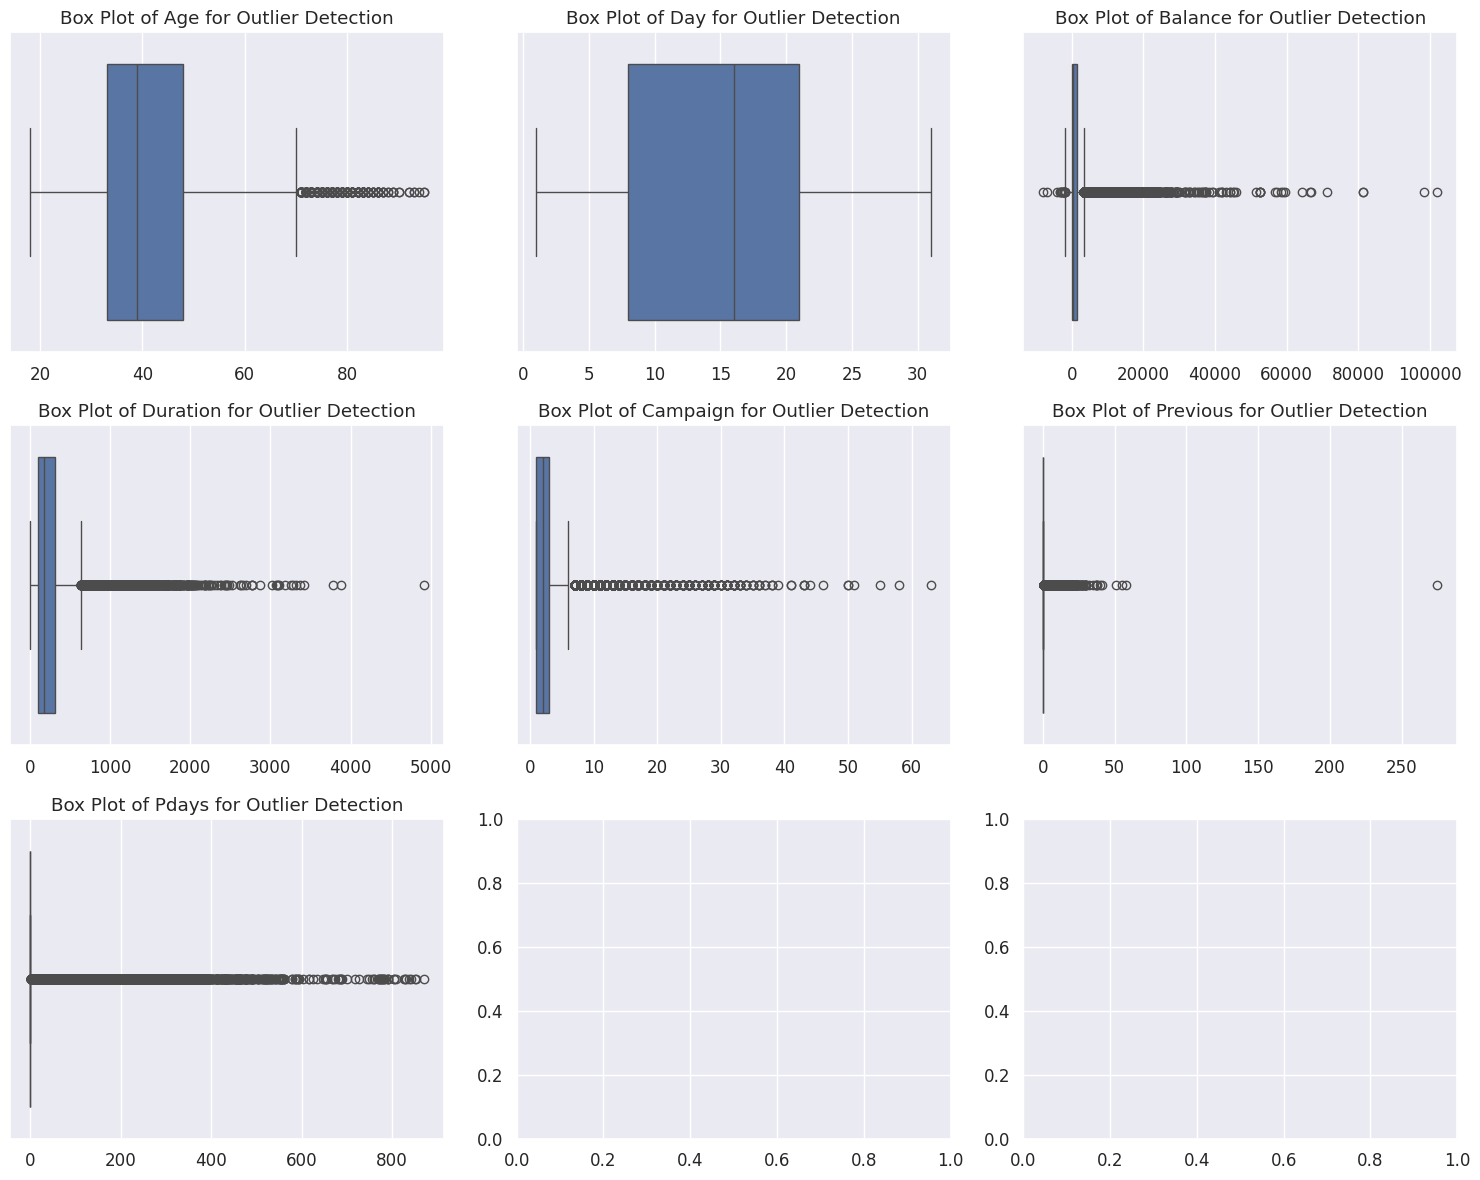

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical attributes to plot for outliers
num_attributes_for_outliers = ['age', 'day', 'balance', 'duration', 'campaign', 'previous', 'pdays']

# Determine grid size for subplots
n_plots_outliers = len(num_attributes_for_outliers)
n_cols_outliers = 3  # You can adjust this for desired layout
n_rows_outliers = (n_plots_outliers + n_cols_outliers - 1) // n_cols_outliers  # Calculate rows needed

# Create a figure and a set of subplots
fig_outliers, axes_outliers = plt.subplots(n_rows_outliers, n_cols_outliers, figsize=(5 * n_cols_outliers, 4 * n_rows_outliers))
axes_outliers = axes_outliers.flatten() # Flatten the 2D array of axes for easy iteration

# Loop through attributes and plot each boxplot
for i_outliers, attribute_outliers in enumerate(num_attributes_for_outliers):
    if i_outliers < n_plots_outliers:
        sns.boxplot(x=df[attribute_outliers], ax=axes_outliers[i_outliers])
        axes_outliers[i_outliers].set_title(f'Box Plot of {attribute_outliers.capitalize()} for Outlier Detection')
        axes_outliers[i_outliers].set_xlabel('') # Hide x-label as title is sufficient
    else:
        fig_outliers.delaxes(axes_outliers[i_outliers]) # Hide empty subplots if any

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

**Interpretation:**
Box plots visualize distribution of each numerical attribute, with specific focus on identifying outliers, which can be considered forms of noisy data.
*   **Age**: Shows concentration of customers within 30-50 age range, with some older individuals appearing as outliers, suggesting diverse age demographic.
*   **Day**: Distribution of contact days is relatively uniform, with no significant outliers, indicating consistent outreach throughout the month.
*   **Balance**: Exhibits wide spread and numerous outliers on higher end, revealing segment of customers with exceptionally large account balances. The median balance is comparatively low.
*   **Duration**: Highly skewed towards shorter call durations, also contains many outliers representing unusually long calls. These longer durations could be significant for successful conversions.
*   **Campaign**: Most customers were contacted a few times, but several outliers indicate individuals contacted high number of times during single campaign, which might suggest ineffective targeting or persistent engagement.
*   **Previous**: Majority of customers had few or no prior contacts, with few outliers showing extensive past interactions.
*   **Pdays**: Dominated by value '-1' (no prior contact), but for those with previous contact, distribution highlights varying days as last interaction, with some very long periods appearing as outliers.

Outliers in features such as `balance`, `duration`, `campaign` & `previous` represent extreme values that might be genuinely rare occurrences or data entry errors. While some outliers (e.g., long `duration` calls leading to successful conversions) can be highly informative, others (e.g., unusually high `campaign` contacts with no conversion) might indicate inefficient processes or noisy data. Decisions on how to handle these outliers (e.g., capping, transformation, or keeping them if they are business-relevant) will depend on further analysis and modeling goals.

#### **1.7.5 Identify Rare Categories in Categorical Attributes**

For categorical data, 'outliers' often refer to categories with very low frequencies.

In [77]:
# Define a threshold for a 'rare' category (e.g., less than 1% of total records for that column)
rarity_threshold = 0.01

print(f"Identifying rare categories (less than {rarity_threshold*100}% of the column's total count):\n")

for col in categorical_attributes:
    value_counts = df[col].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < rarity_threshold]

    if not rare_categories.empty:
        print(f"Attribute '{col}':")
        for category, proportion in rare_categories.items():
            print(f"  - '{category}': {proportion:.2%} (count: {df[col].value_counts()[category]}) ")
    else:
        print(f"Attribute '{col}': No categories found below the {rarity_threshold*100}% rarity threshold.")

Identifying rare categories (less than 1.0% of the column's total count):

Attribute 'job':
  - 'unknown': 0.64% (count: 288) 
Attribute 'marital': No categories found below the 1.0% rarity threshold.
Attribute 'education': No categories found below the 1.0% rarity threshold.
Attribute 'default': No categories found below the 1.0% rarity threshold.
Attribute 'housing': No categories found below the 1.0% rarity threshold.
Attribute 'loan': No categories found below the 1.0% rarity threshold.
Attribute 'contact': No categories found below the 1.0% rarity threshold.
Attribute 'month':
  - 'dec': 0.47% (count: 214) 
Attribute 'poutcome': No categories found below the 1.0% rarity threshold.


**Interpretation:**
This analysis identified rare categories within dataset, specifically those occurring in less than 1% of total records for respective columns.
*   **Job**: The 'unknown' category is rare, making up 0.64% of job entrie, suggests job information missing or not classified for small portion of clients.
*   **Month**: Month 'dec' (December) is rare contact month, representing 0.47% of all contacts, indicates marketing campaigns are infrequent in December.

Above findings are crucial for informing feature engineering strategies, for deciding on imputation methods if 'unknown' signifies missing data. Understanding such infrequent occurrences can also help detect potential data entry issues or highlight specific periods/groups which receive less attention in marketing efforts.

#### **1.7.6 Verify 'loan' Column Conversion**
Displaying value counts for 'loan' to confirm numerical conversion.

In [78]:
df["loan"].value_counts()

,count
loan,
no,37967
yes,7244


#### **1.7.7 Rename Target Column 'y' to 'deposit'**
Renaming the target column for clarity and problem statement alignment.

In [79]:
# rename target column
df.rename(columns ={'y':'deposit'} , inplace = True)

In [80]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Interpretation:** Rename target column `y` to `deposit` to make DataFrame more understandable and align with problem statement of predicting whether a customer will subscribe to term deposit.

### **1.8 Exploratory Data Analysis**

### **1.8.1 Numerical Feature Distributions**

This section consolidates the visualizations for numerical attribute distributions, using histograms to show frequency and box plots for a quick view of central tendency and potential outliers.

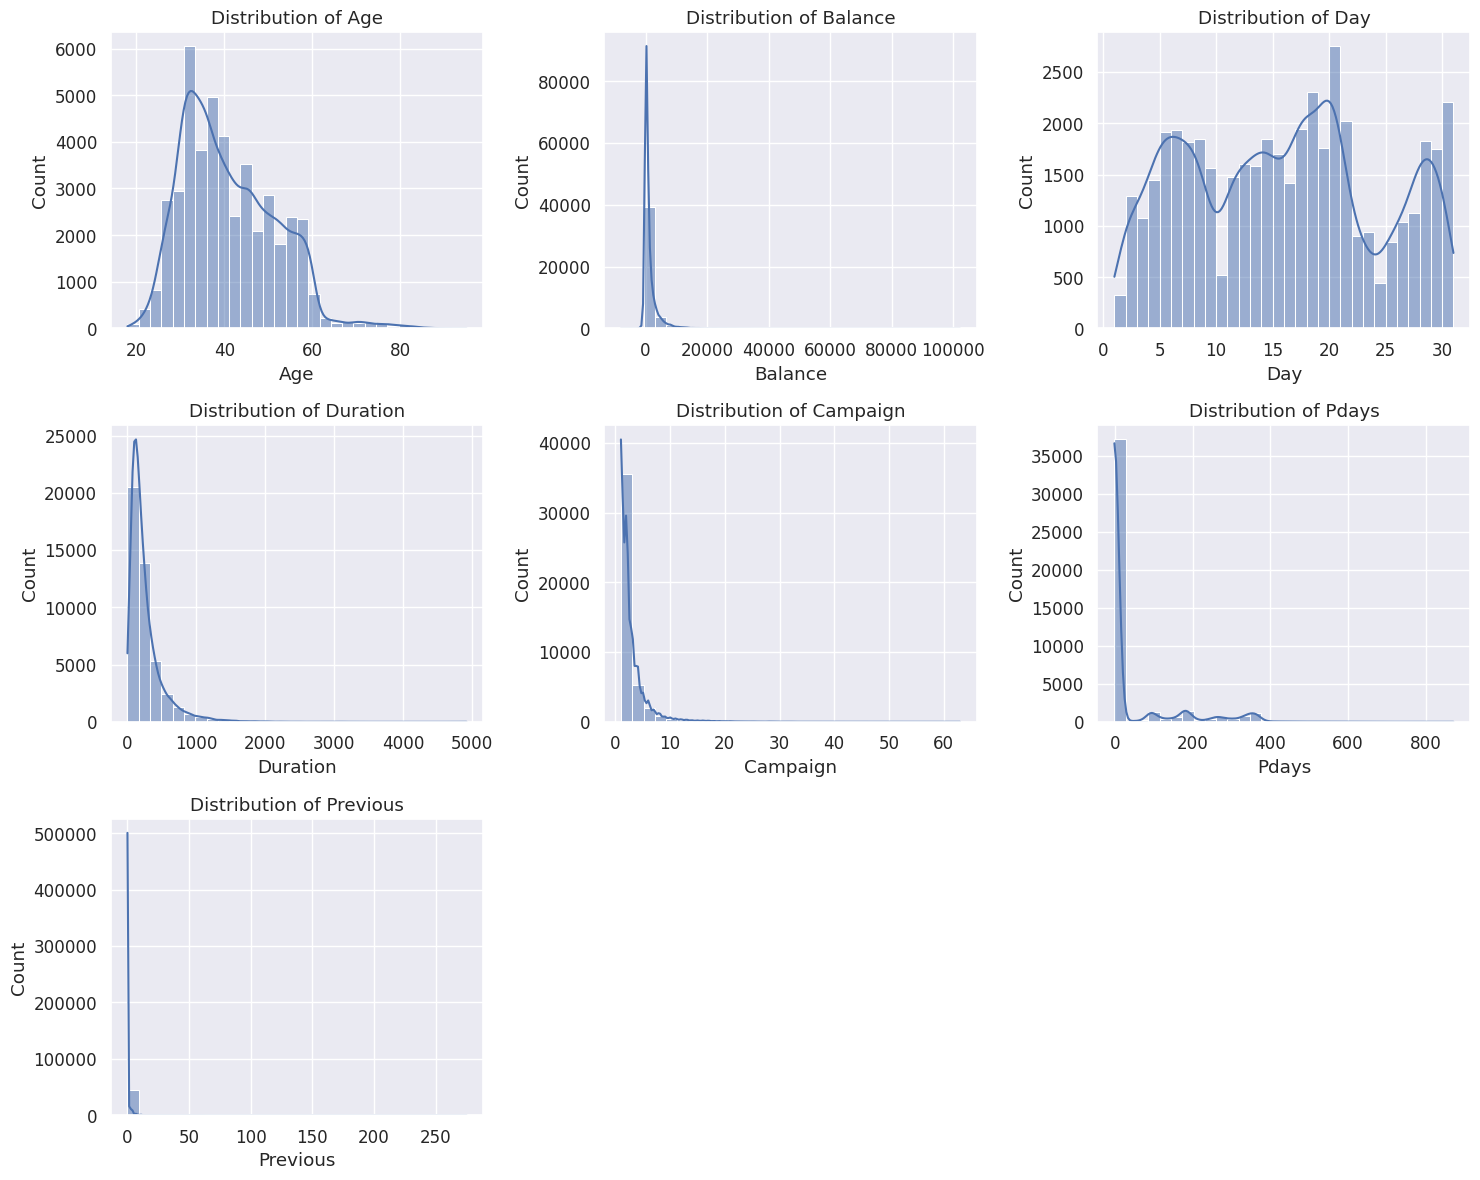

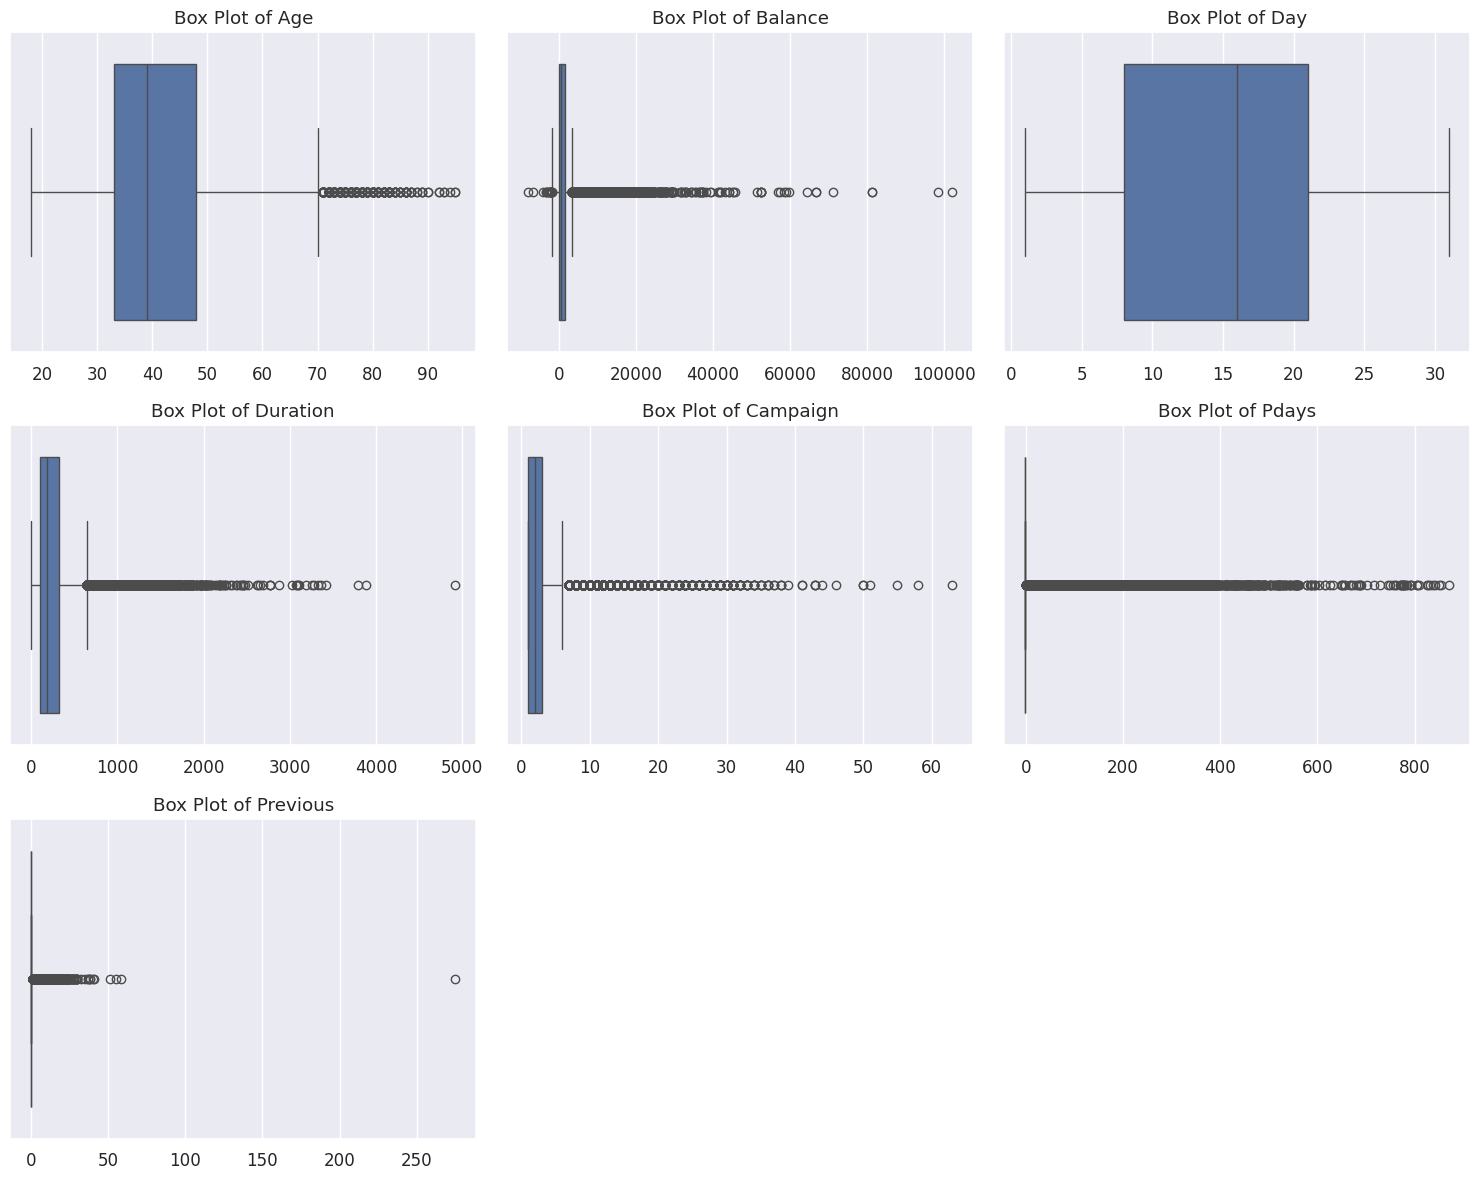

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical attributes to visualize
num_attributes = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Determine grid size for subplots (e.g., 3 columns)
n_plots = len(num_attributes)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, attribute in enumerate(num_attributes):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[attribute], kde=True, bins=30) # Histogram with KDE
    plt.title(f'Distribution of {attribute.capitalize()}')
    plt.xlabel(attribute.capitalize())
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, attribute in enumerate(num_attributes):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[attribute]) # Box plot
    plt.title(f'Box Plot of {attribute.capitalize()}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

#### **Interpretation:**
Comprehensive overview of the numerical feature distributions.
-   **Age, Day, Campaign, Previous, Pdays**: Histograms reveal frequency distribution, often showing skewness (e.g., most campaigns are short, many have few previous contacts). Box plots highlight median, quartiles & potential outliers, indicating spread & presence of extreme values.
-   **Balance, Duration**: Features often show significant skewness & numerous outliers, suggesting few customers with very high balances or unusually long contact durations. Such distributions are crucial for understanding typical customer profile & identifying exceptional cases.

Overall, plots inform subsequent data preprocessing steps such as outlier handling or feature transformations, to ensure numerical features are appropriately prepared for modeling.

### **1.8.2 Categorical Feature Value Distributions**

Provides frequency counts for all categorical attributes, which is essential for understanding distribution of categories within each feature.

In [82]:
import pandas as pd

categorical_attributes_for_counts = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

print("Value Counts for Categorical Attributes:")
for col in categorical_attributes_for_counts:
    print(f"\n--- {col.capitalize()} ---")
    print(df[col].value_counts())

Value Counts for Categorical Attributes:

--- Job ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

--- Marital ---
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

--- Education ---
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

--- Default ---
default
no     44396
yes      815
Name: count, dtype: int64

--- Housing ---
housing
yes    25130
no     20081
Name: count, dtype: int64

--- Loan ---
loan
no     37967
yes     7244
Name: count, dtype: int64

--- Contact ---
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

--- Month ---
month
may    13766
jul     6895
aug     6247
jun     5341
nov     39

#### **Interpretation:**
Categorical feature value counts provides clear understanding of distribution of different categories within each feature.
-   **Dominant Categories**: Many features exhibit dominant category (e.g., 'blue-collar' for job, 'married' for marital status, 'no' for default/loan/housing), which indicates most common characteristics within customer base.
-   **Less Frequent Categories**: Identifies categories with fewer occurrences, representing niche segments or require special handling during encoding.
-   **Campaign Activity**: Peak months for campaigns (e.g., 'may') & outcomes of previous campaigns ('unknown' being prevalent indicates many new contacts or unrecorded histories).

Counts are fundamental for understanding dataset's composition, assessing potential class imbalances within categorical feature & guiding choice of encoding strategies (e.g., one-hot encoding, target encoding) for machine learning models.

### **1.8.3 Numerical Features vs. Deposit Outcome Visualizations**

Here, violin plots are used to compare the distributions of numerical features against the target variable `deposit`, helping to identify potential relationships.

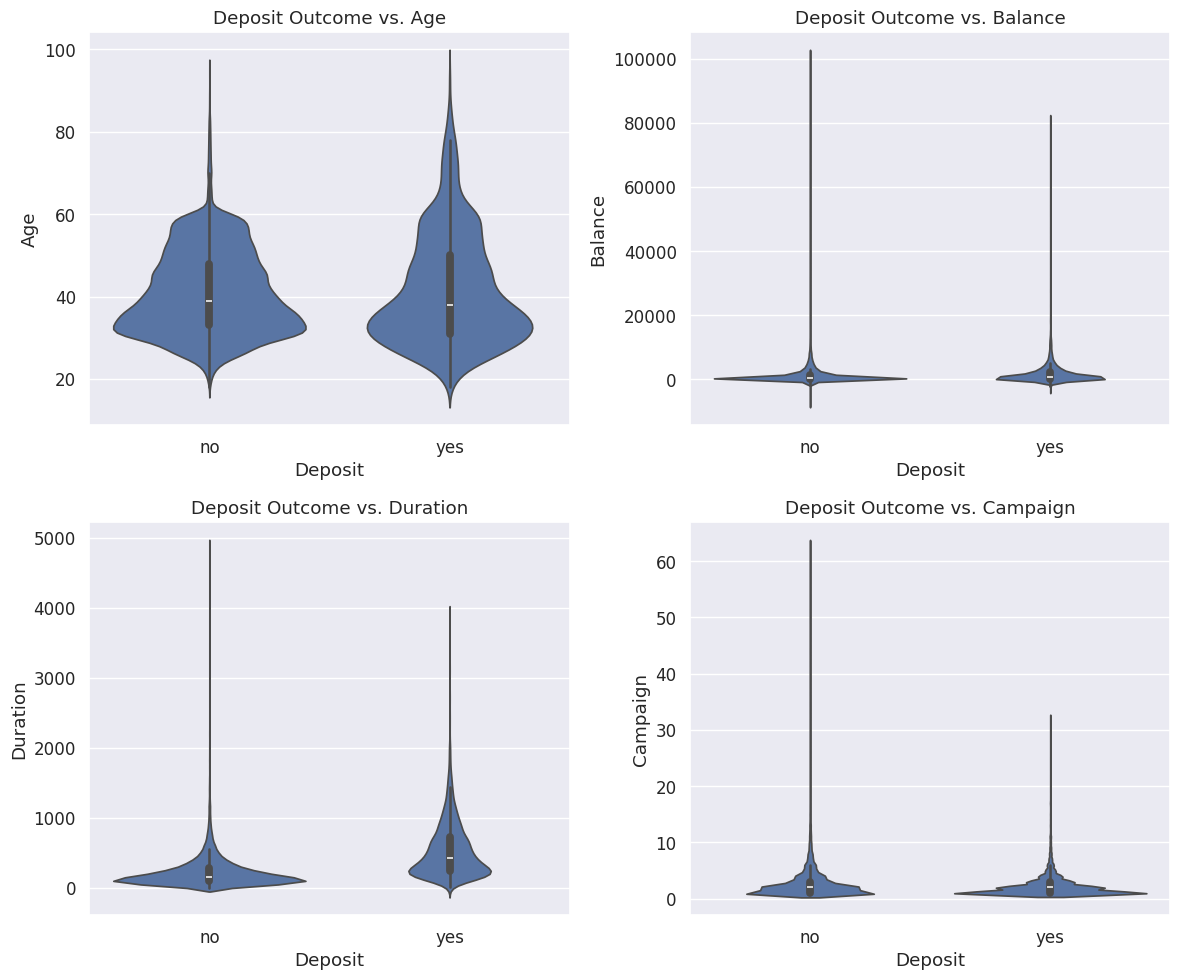

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

num_attributes_for_violin = ['age', 'balance', 'duration', 'campaign'] # Add other relevant numerical features

n_plots = len(num_attributes_for_violin)
n_cols = 2 # Adjust for desired layout
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(6 * n_cols, 5 * n_rows))

for i, attribute in enumerate(num_attributes_for_violin):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(x="deposit", y=attribute, data=df)
    plt.title(f'Deposit Outcome vs. {attribute.capitalize()}')
    plt.xlabel('Deposit')
    plt.ylabel(attribute.capitalize())

plt.tight_layout()
plt.show()

### **Interpretation:**
Plots effectively visualize relationship between key numerical features and `deposit` outcome.
-   **Duration**: Customers who subscribed ('yes') generally have significantly longer contact durations than those who did not ('no'), which suggests, more engaged conversations are crucial for successful term deposit subscriptions.
-   **Balance**: Subscribers tend to have higher average and more varied bank balances compared to non-subscribers, indicating clients greater financial capacity or different financial behaviors are more prone to deposit.
-   **Age**: While distributions might overlap, subtle differences can be observed, indicating if certain age groups are more receptive to term deposits.
-   **Campaign**: Often, subscribers show slightly lower number of campaign contacts, implying that over-contacting can be counterproductive or that more targeted campaigns are effective.

### **1.8.4 Consolidated Categorical Feature vs. Deposit Outcome Visualizations**

This section provides stacked bar charts to visualize the relationship between each categorical feature and the `deposit` outcome, highlighting how different categories influence subscription rates.

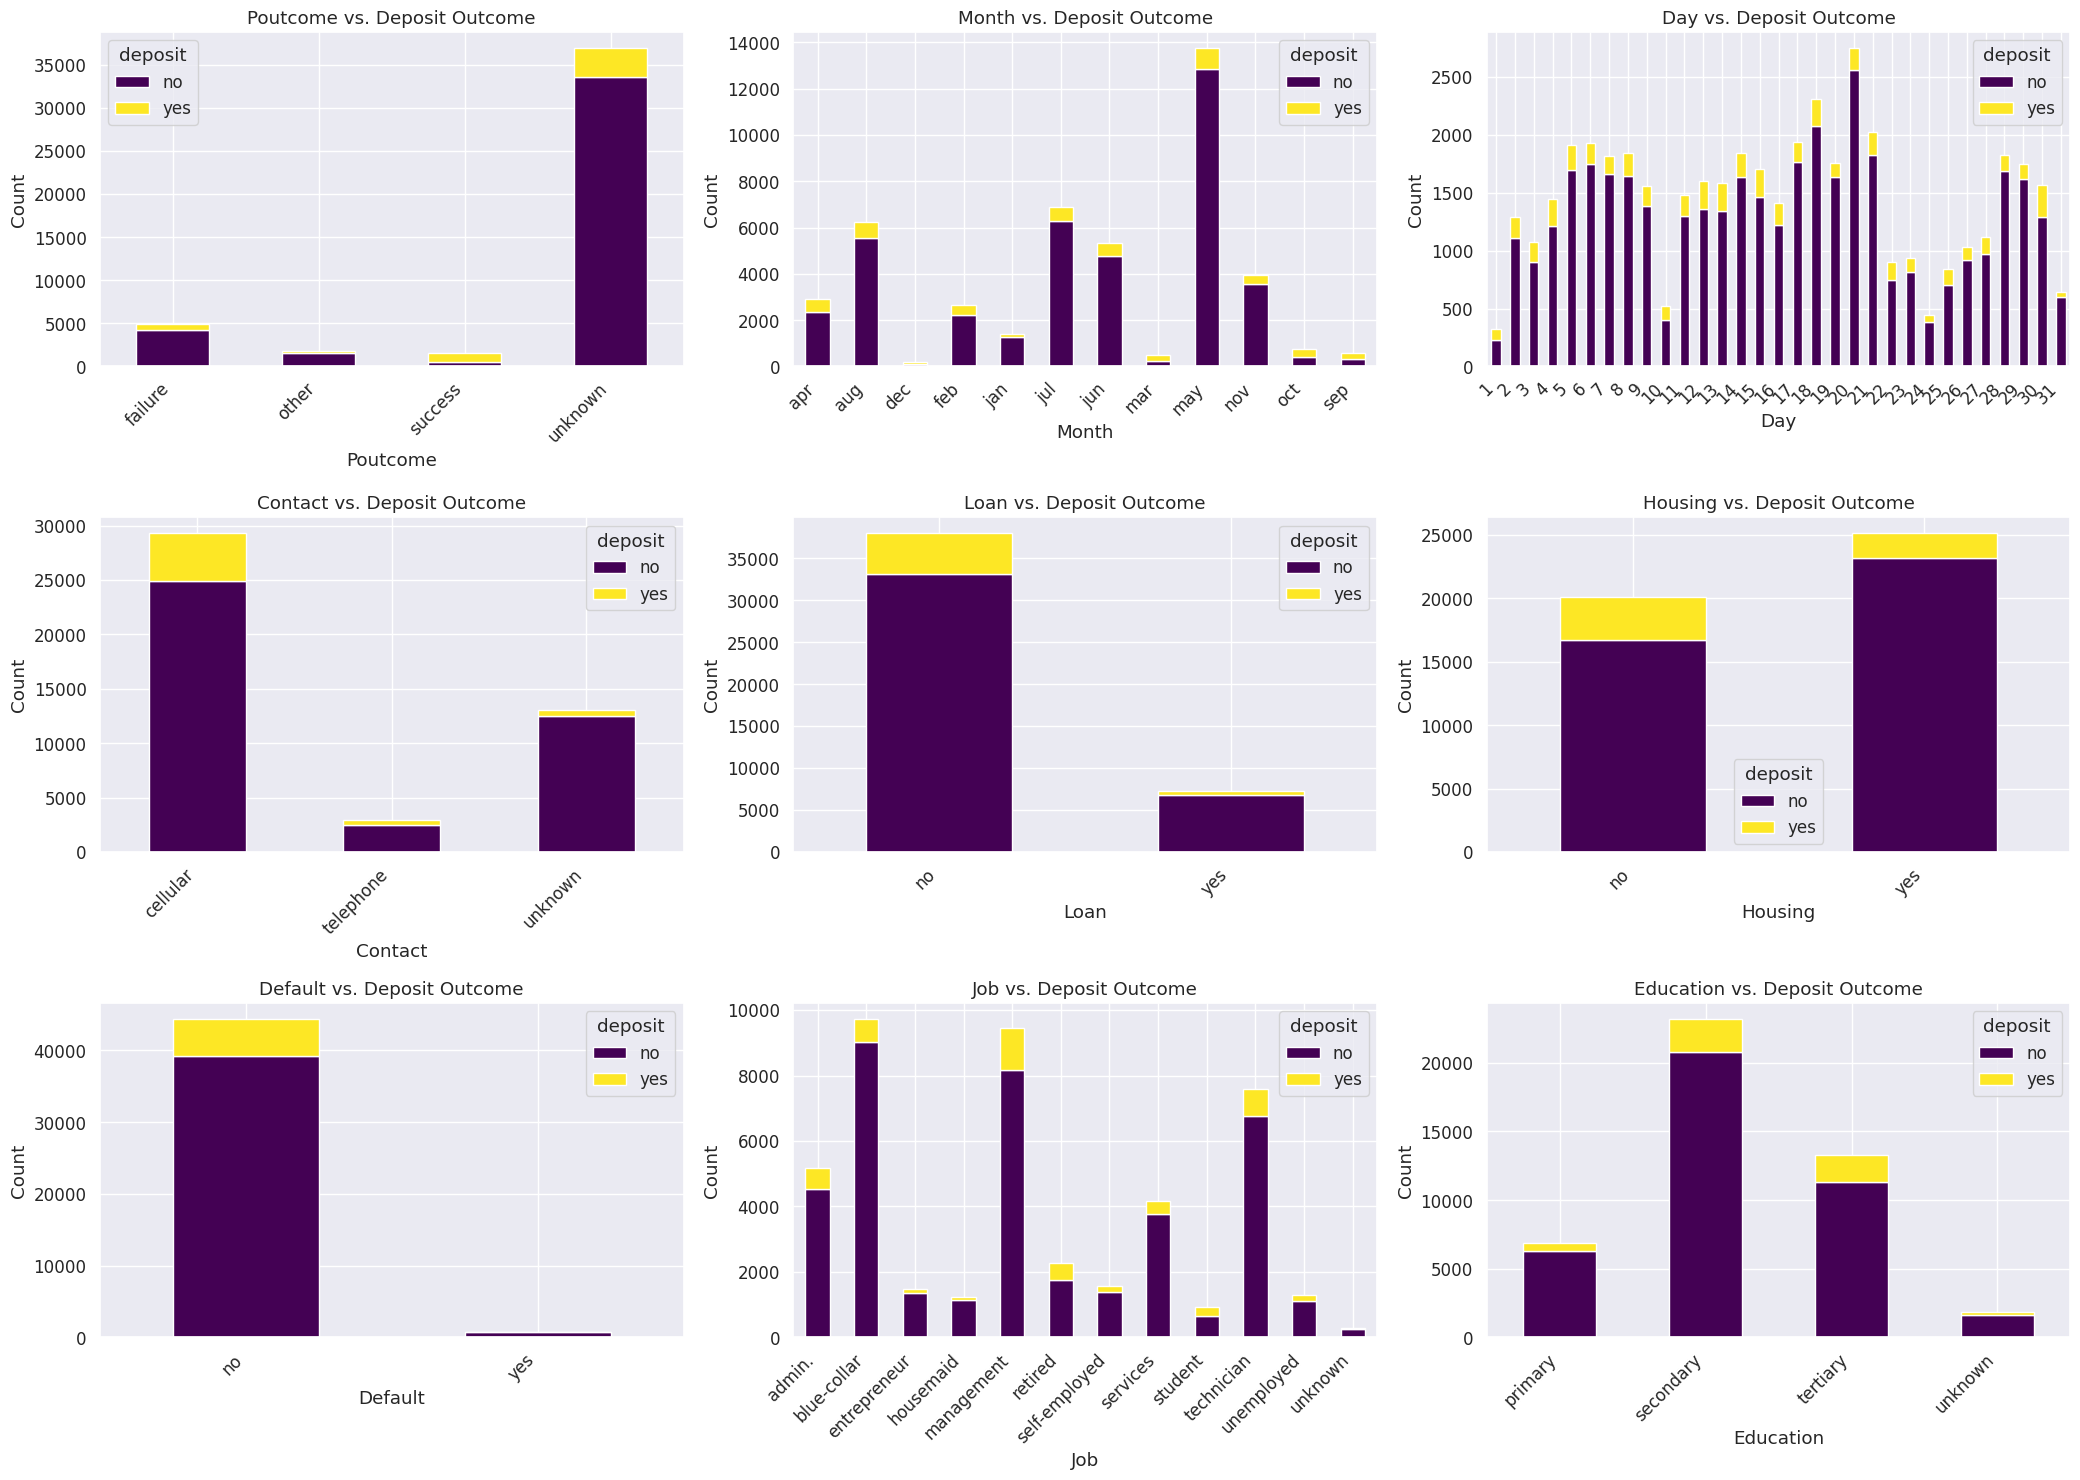

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_attributes_for_bar = ['poutcome', 'month', 'day', 'contact', 'loan', 'housing', 'default', 'job', 'education']

n_plots = len(categorical_attributes_for_bar)
n_cols = 3 # Adjust for desired layout
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(7 * n_cols, 5 * n_rows))

for i, col in enumerate(categorical_attributes_for_bar):
    plt.subplot(n_rows, n_cols, i + 1)
    types = df.groupby(col)['deposit'].value_counts(normalize=False).unstack()
    types.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'{col.capitalize()} vs. Deposit Outcome')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **Interpretation:**
Bar charts reveal critical insights into how different categorical attributes influence term deposit subscription rates.
-   **Poutcome ('success')**: Customers from previous campaigns with 'success' outcome are far more likely to subscribe again, highlighting importance of past engagement. Conversely, 'unknown' or 'failure' outcomes have much lower success rates.
-   **Month ('mar', 'oct', 'dec', 'sep')**: Certain months show disproportionately higher subscription rates, even if they have fewer overall contacts, suggesting optimal timing for campaigns.
-   **Contact, Housing, Loan, Default**: 'Cellular' contact, no housing loan, no personal loan, and no credit default are generally associated with higher subscription likelihoods, which identifies financially stable & accessible segments.
-   **Job, Education**: Specific job roles (e.g., 'student', 'retired') & education levels (e.g., 'tertiary') may show higher propensities for subscription. This guides targeted marketing efforts.

Visualizations are essential for understanding customer segments, identifying favorable conditions for marketing & prioritizing features for model building based on influence on target variable.

**Interpretation:** This re-plot reinforces the visual comparison of 'duration' distributions between deposit and non-deposit groups, confirming any observed patterns from the previous plot.

Duration : The duration of call in seconds when the client was contacted last time. A histogram is plotted for this and there are very less number of clients having very long duration. Violin plot indicates that people with longer duration have more possibility of saying yes to deposit.

### **1.9 Data PreProcessing**
Encodes categorical features into numerical formats, handling any remaining data inconsistencies & splits data into training/testing sets to ensuring data is in a suitable format for model training & evaluation.


#### **1.9.2 Handling missing values**
As no missing values were found, no action is required to remove them, which simplifies data cleaning process.

### **1.9.2 Encode Binary Categorical Features**

In [85]:
binary_mappings = {
    'deposit': {'yes': 1, 'no': 0},
    'loan': {'no': 1, 'yes': 0},
    'default': {'no': 1, 'yes': 0},
    'housing': {'no': 1, 'yes': 0}
}

for col, mapping in binary_mappings.items():
    df[col].replace(to_replace=mapping, inplace=True)

print("First 5 rows of DataFrame after binary categorical feature encoding:")
display(df.head())

First 5 rows of DataFrame after binary categorical feature encoding:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,1,2143,0,1,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,1,29,0,1,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,1,2,0,0,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,1,1506,0,1,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,1,1,1,1,unknown,5,may,198,1,-1,0,unknown,0


**Interpretation:**
Converting binary categorical features (like `deposit`, `loan`, `default`, `housing`) into numerical representations (0 and 1) is a fundamental step for machine learning algorithms, which require numerical inputs. This transformation makes these features compatible with various models and simplifies further processing. For `deposit`, 'yes' is mapped to 1 (indicating subscription) and 'no' to 0. For `loan`, `default`, and `housing`, 'no' is mapped to 1 and 'yes' to 0, which might imply the absence of a loan/default is considered a 'positive' or base state. The `df.head()` display confirms the successful application of these numerical conversions.

### **1.9.3 One-Hot Encode Multi-Category Features**

In [86]:
# It's assumed 'divorced' was already dropped by `df = df.drop('divorced',axis = 1)` in a previous cell.
# To handle potential remaining 'marital' column and avoid multicollinearity, we re-encode with drop_first=True.
# If 'divorced' was not dropped, drop_first=True on 'marital' would handle it by implicitly dropping one category.

# Perform One-Hot Encoding for multi-category nominal features: 'marital', 'education', 'job', 'contact', 'month', 'poutcome'.
# Drop the original categorical column and one of the newly created dummy columns to prevent multicollinearity.
# 'unknown' categories are also dropped where they are less informative or redundant (e.g., education, job, contact).

# Marital Status: drop_first=True implicitly drops one category (e.g., 'divorced' if it was present, or 'single'/'married').
# If 'divorced' column still exists from an earlier separate drop, it will be handled by the OHE.
if 'marital' in df.columns:
    one_hot_marital = pd.get_dummies(df['marital'], prefix='marital', drop_first=True)
    df = df.drop('marital', axis=1)
    df = df.join(one_hot_marital)

# Education: Drop 'education_unknown' as identified as less informative during EDA.
if 'education' in df.columns:
    one_hot_education = pd.get_dummies(df['education'], prefix='education')
    df = df.drop('education', axis=1)
    if 'education_unknown' in one_hot_education.columns:
        one_hot_education = one_hot_education.drop('education_unknown', axis=1)
    df = df.join(one_hot_education)

# Job: Drop 'job_unknown' as identified as less informative during EDA.
if 'job' in df.columns:
    one_hot_job = pd.get_dummies(df['job'], prefix='job')
    df = df.drop('job', axis=1)
    if 'job_unknown' in one_hot_job.columns:
        one_hot_job = one_hot_job.drop('job_unknown', axis=1)
    df = df.join(one_hot_job)

# Contact: Drop 'contact_unknown' as identified as less informative during EDA.
if 'contact' in df.columns:
    one_hot_contact = pd.get_dummies(df['contact'], prefix='contact')
    df = df.drop('contact', axis=1)
    if 'contact_unknown' in one_hot_contact.columns:
        one_hot_contact = one_hot_contact.drop('contact_unknown', axis=1)
    df = df.join(one_hot_contact)

# Month: Drop 'month_dec' as it was identified as a rare category and to prevent multicollinearity.
if 'month' in df.columns:
    one_hot_month = pd.get_dummies(df['month'], prefix='month')
    df = df.drop('month', axis=1)
    if 'month_dec' in one_hot_month.columns:
        one_hot_month = one_hot_month.drop('month_dec', axis=1)
    df = df.join(one_hot_month)

# Poutcome: Drop 'poutcome_other' to prevent multicollinearity, 'unknown' is also a candidate but 'other' was specified before.
if 'poutcome' in df.columns:
    one_hot_poutcome = pd.get_dummies(df['poutcome'], prefix='poutcome')
    df = df.drop('poutcome', axis=1)
    if 'poutcome_other' in one_hot_poutcome.columns:
        one_hot_poutcome = one_hot_poutcome.drop('poutcome_other', axis=1)
    df = df.join(one_hot_poutcome)

print("First 5 rows of DataFrame after one-hot encoding multi-category features:")
display(df.head())

First 5 rows of DataFrame after one-hot encoding multi-category features:


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_success,poutcome_unknown
0,58,1,2143,0,1,5,261,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,44,1,29,0,1,5,151,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,33,1,2,0,0,5,76,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
3,47,1,1506,0,1,5,92,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
4,33,1,1,1,1,5,198,1,-1,0,...,False,False,False,True,False,False,False,False,False,True


**Interpretation:**
One-hot encoding is applied to nominal categorical features (`marital`, `education`, `job`, `contact`, `month`, `poutcome`) to convert them into a numerical format suitable for machine learning models. Each unique category is transformed into a new binary column. To prevent multicollinearity (the "dummy variable trap"), one category from each feature is typically dropped (e.g., using `drop_first=True` or explicitly removing one column like `education_unknown` or `month_dec`). This process ensures that the model can interpret these features without encountering linear dependencies, making the dataset ready for model training. The `df.head()` display confirms the addition of these new encoded columns and the removal of the original categorical ones.

#### **1.9.4 Check DataFrame Information**
Displaying `df.info()` to confirm processed categorical features and readiness.

In [87]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   default              45211 non-null  int64
 2   balance              45211 non-null  int64
 3   housing              45211 non-null  int64
 4   loan                 45211 non-null  int64
 5   day                  45211 non-null  int64
 6   duration             45211 non-null  int64
 7   campaign             45211 non-null  int64
 8   pdays                45211 non-null  int64
 9   previous             45211 non-null  int64
 10  deposit              45211 non-null  int64
 11  marital_married      45211 non-null  bool 
 12  marital_single       45211 non-null  bool 
 13  education_primary    45211 non-null  bool 
 14  education_secondary  45211 non-null  bool 
 15  education_tertiary   45211 non-null  bool 
 16  job_admin.           4

**Interpretation:** Confirms all categorical features intended for one-hot encoding have been processed & DataFrame now consists primarily of numerical & boolean types suitable for machine learning.

#### **1.9.5 Correlation with Class variable 'deposit'**
Compute linear correlation between each feature and 'deposit' target variable to identify potential predictors and create bar plot to visually rank feature correlation with target variable.

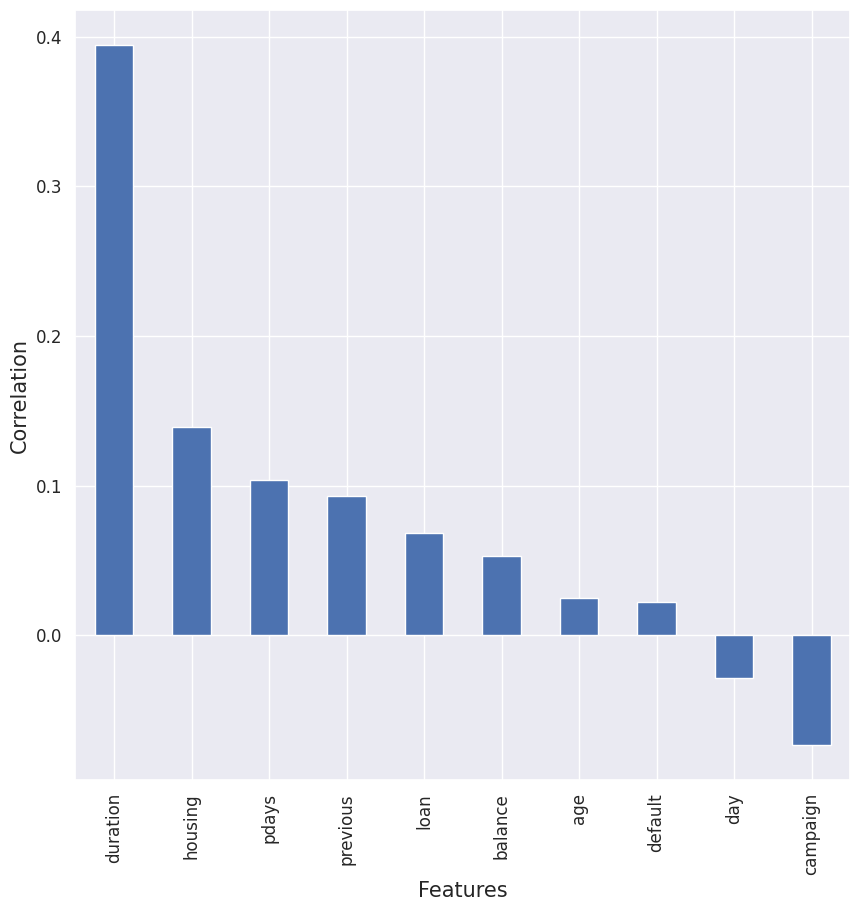

In [88]:
# Copying original dataframe and selecting only numerical columns for correlation
bank_numeric = df.select_dtypes(include=np.number).copy()

# Ensure 'deposit' is treated as numeric if it's boolean
if 'deposit' in bank_numeric.columns and bank_numeric['deposit'].dtype == bool:
    bank_numeric['deposit'] = bank_numeric['deposit'].astype(int)

# Calculate correlation with 'deposit' for numerical features
CorrBank = bank_numeric.drop("deposit", axis=1).apply(lambda x: x.corr(bank_numeric.deposit))

# puttinh in descending order
Corr2=CorrBank.sort_values(ascending=False)

Corr2.plot.bar()
plt.xlabel("Features", fontsize=15)
plt.ylabel("Correlation", fontsize=15)


plt.show()

#### **Interpretation:** The bar plot provides a clear visual ranking of features by their correlation strength with the target variable, 'deposit'.

- **Positive Correlation**: `duration` shows highest positive correlation (0.39), indicating longer contact durations are associated with higher likelihood of subscribing to term deposit. Other positively correlated features include `housing`, `pdays`, `previous`, `loan`, `balance`, `age` & `default` (though `default`'s correlation is very low).

- **Negative Correlation**: `campaign` exhibits highest negative correlation (-0.07), suggesting an increased number of contacts during current campaign might be associated with lower likelihood of subscription. `day` also shows slight negative correlation (-0.028).

Visualization helps identify most influential features for predicting term deposit subscriptions, with `duration` standing out as primary positive predictor & `campaign` as key negative predictor (in terms of linear correlation).

#### **1.9.6 Split Dataset into Training & Testing Sets**
Dividing data 80% train, 20% test for unbiased model evaluation.

In [89]:
# Copying original dataframe
bank= df.copy()

# Select Features
feature = bank.drop('deposit', axis=1)

# Select Target
target = bank['deposit']

# Set Training and Testing Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feature,target,test_size=0.2,random_state=1)

# Show the Training and Testing Data
print('Shape of training feature:', X_train.shape)
print('Shape of testing feature:', X_test.shape)
print('Shape of training label:', y_train.shape)
print('Shape of training label:', y_test.shape)

Shape of training feature: (36168, 42)
Shape of testing feature: (9043, 42)
Shape of training label: (36168,)
Shape of training label: (9043,)


**Interpretation:** Splitting dataset into training & testing sets is a crucial step to ensure model's performance is evaluated unbiasedly on unseen data. The chosen 80:20 ratio is common practice, providing substantial portion for model to learn patterns from while reserving sufficient, independent dataset to assess its generalization capabilities, which prevents overfitting and gives more reliable indication of how model will perform on new, real-world data.

The provided shapes confirm successful division.
- **Training Features (`X_train`)**: `(36168, 42)` indicates the model will be trained on 36,168 samples, each with 42 features.
- **Testing Features (`X_test`)**: `(9043, 42)` indicates the model will be evaluated on 9,043 unseen samples, each with 42 features.
- **Training Labels (`y_train`)**: `(36168,)` represents the 36,168 corresponding target labels for the training data.
- **Testing Labels (`y_test`)**: `(9043,)` represents the 9,043 corresponding target labels for the testing data.

Above dimensions ensure that training set is robust enough for model learning, and test set is sufficiently large for reliable evaluation of model's performance on new data.

#### **1.9.5 Scale Numeric Data**
Scale numerical data to avoid outlier presence which can significantly affect model performance. Use StandardScaler to scale all numerical columns. The scaling will be done using formula **Z=X-U/S**.
 - Z: scaled value
 - X: original value
 - U: mean of data
 - S: standard deviation of data**

In [90]:
scaler=StandardScaler()
X_train =scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

**Interpretation:** Feature scaling is performed to normalize the range of independent variables. `StandardScaler` transforms data to have a mean of 0 and standard deviation of 1, which is crucial for algorithms sensitive to feature magnitudes, like KNN and neural networks. Scaling *after* splitting prevents data leakage from the test set into the training process.

### **2. Model Training & Evaluation**
  1. Train at least 2 baseline supervised models:
      * Logistic Regression
      * Naive Bayes (optional)
  2. Evaluate using
      * Confusion Matrix
      * Accuracy
      * Precision, Recall, F1-score
      * ROC-AUC (if applicable)

#### **2.1 SMOTE (Synthetic Minority Over-sampling Technique): Handle Class Imbalance**
As the prediction is to determine whether a client will subscribe to term deposit (deposit = 'yes' or 'no'). Basis earlier exploration, significant majority of clients did not subscribe ('no'), while much smaller portion did subscribe ('yes') which makes  'yes' class minority class. SMOTE is being applied to combat such class imbalance. Without it, models would struggle to learn patterns associated with minority class, precisely what bank wants to identify for successful marketing campaigns.
  - Need: Model trained on a dataset where, s90% of clients say 'no' to a deposit and only 10% say 'yes' might simply predict 'no' for almost every client, practically useless for bank as it fails to identify valuable 10% who are likely to subscribe. The bank needs to identify potential subscribers, not just confirm who isn't subscribing.
  -  Necessity:
In case imbalance is not addressed, model would have very low recall for 'yes' class. Low recall means model misses many potential subscribers, leading to lost business opportunities. By artificially balancing training set, SMOTE forces model to pay more attention to characteristics of 'yes' class, improving its ability to correctly identify crucial instances.



In [91]:
# smote
import imblearn.over_sampling
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
ratio = {1 : n_pos * 4, 0 : n_neg}

smote = imblearn.over_sampling.SMOTE(sampling_strategy=ratio, random_state = 42)

X_train, y_train = smote.fit_resample(X_train, y_train)

**Interpretation:** To balance class distribution in training set, crucial for improving model's ability to correctly predict minority class ('deposit' = 1), as imbalanced datasets lead to models biased towards majority class, 4x oversampling aims to reduce such bias.

#### **2.2 Define Model Evaluation Helper Function**
Create reusable function for calculating key classification metrics, namely accuracy, precision, recall, F1, AUC, confusion matrix for model assessment.

In [92]:
def evaluate_model(model, x_test, y_test):
    from sklearn import metrics

    # Predict Test Data
    y_pred = model.predict(x_test)

    # Calculate accuracy, precision, recall, f1-score, and kappa score
    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

    # Calculate area under curve (AUC)
    y_pred_proba = model.predict_proba(x_test)[::,1]
    fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
    auc = metrics.roc_auc_score(y_test, y_pred_proba)

    # Display confussion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,'fpr': fpr, 'tpr': tpr, 'auc': auc, 'cm': cm}

#### **2.3 Logistic Regression**
Logistic Regression is a statistical model which uses Logistic function to model binary dependent variable, for predicting probability of a binary outcome although many more complex extensions exist. It's used

Accuracy: 0.8794647793873714
Precision: 0.4866666666666667
Recall: 0.6952380952380952
F1 Score: 0.5725490196078431
ROC-AUC [Receiver Operating Characteristic - Area Under Curve]: 0.908415935372022
Confusion Matrix:
 [[7223  770]
 [ 320  730]]


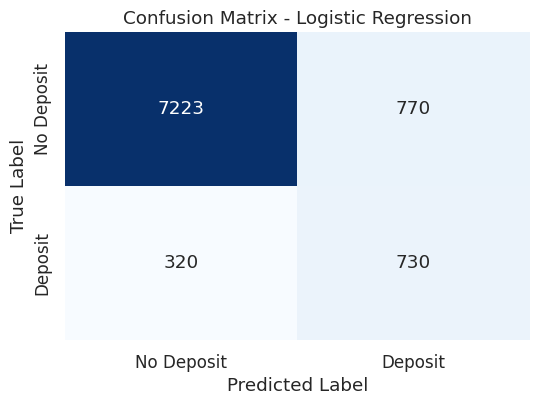

In [93]:
from sklearn.linear_model import LogisticRegression

# Building Logistic Regression model
lr = LogisticRegression(random_state=0)
lr.fit(X_train, y_train)

# Evaluate Model
lr_eval = evaluate_model(lr, X_test, y_test)

# Print result
print('Accuracy:', lr_eval['acc'])
print('Precision:', lr_eval['prec'])
print('Recall:', lr_eval['rec'])
print('F1 Score:', lr_eval['f1'])
print('ROC-AUC [Receiver Operating Characteristic - Area Under Curve]:', lr_eval['auc'])
print('Confusion Matrix:\n', lr_eval['cm'])

# Plotting the confusion matrix for Logistic Regression
plt.figure(figsize=(6, 4))
sns.heatmap(lr_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#### **Interpretation:** The model achieved strong performance with an 87.95% Accuracy and 0.9084 AUC, highlighting its ability to identify term deposit subscribers (69.52% Recall). However, a 48.67% Precision suggests a need to reduce false positives for more efficient marketing. Further comparison with other models and hyperparameter tuning are recommended.

#### **2.4 Naive Bayes**
Technique for constructing classifiers: models that assign class labels to problem instances, represented as vectors of feature values, where the class labels are drawn from some finite set. There is not a single algorithm for training such classifiers, but a family of algorithms based on a common principle: all naive Bayes classifiers assume that the value of a particular feature is independent of the value of any other feature, given the class variable. Below are the Bayes theorem formula:


For example, given:

A doctor knows that meningitis causes stiff neck 50% of the time
Prior probability of any patient having meningitis is 1/50,000
Prior probability of any patient having stiff neck is 1/20
Then the probability of patient who have stiff neck to also have meningitis is:





Accuracy: 0.84739577573814
Precision: 0.3894101876675603
Recall: 0.5533333333333333
F1 Score: 0.45712037765538943
 [Receiver Operating Characteristic - Area Under Curve]: 0.8066458150882023
Confusion Matrix:
 [[7082  911]
 [ 469  581]]


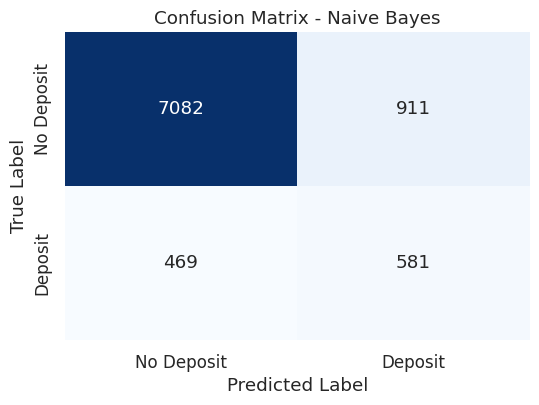

In [94]:
from sklearn.naive_bayes import GaussianNB

# Building Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)
# Evaluate Model
nb_eval = evaluate_model(nb, X_test, y_test)

# Print result
print('Accuracy:', nb_eval['acc'])
print('Precision:', nb_eval['prec'])
print('Recall:', nb_eval['rec'])
print('F1 Score:', nb_eval['f1'])
print(' [Receiver Operating Characteristic - Area Under Curve]:', nb_eval['auc'])
print('Confusion Matrix:\n', nb_eval['cm'])

# Plotting the confusion matrix for Naive Bayes
plt.figure(figsize=(6, 4))
sns.heatmap(nb_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

**Interpretation:**
Assumes features are conditionally independent given the class, is trained. Its performance is evaluated to see how this probabilistic model fares in predicting term deposits.

### **3. Decision Tree Learning & Interpretation**
  1. Train a Decision Tree Classifier
  2. Tune:
      * max_depth
      * min_samples_split
      * min_samples_leaf
  3. Interpret the model:
      * Feature importance
      * Explain at least 2 decision paths (if possible)

#### **3.1 Decision Tree with Hyperparameter Tuning**
Used to determine course of action where each branch of the tree represents possible decision, occurrence or reaction. Training Decision Tree model with entropy & evaluating performance.

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score: 0.8213
Accuracy: 0.8659736813004534
Precision: 0.4363207547169811
Recall: 0.5285714285714286
F1 Score: 0.4780361757105943
Area Under Curve: 0.7194339690085968
Confusion Matrix:
 [[7276  717]
 [ 495  555]]


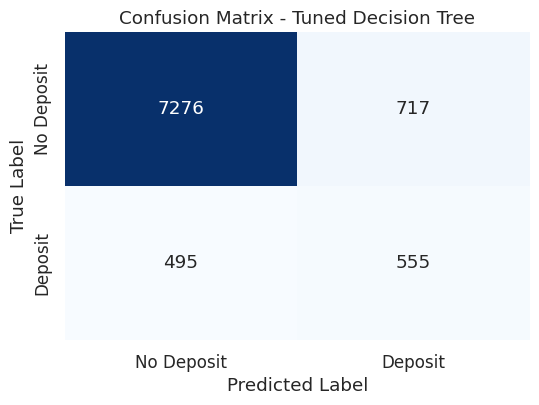

In [95]:
# Building Decision Tree model
dtc = tree.DecisionTreeClassifier(criterion = 'entropy',random_state=0)

# Define parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to find the best parameters
grid_search.fit(X_train, y_train)

# Get the best estimator
best_dtc = grid_search.best_estimator_

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

# Evaluate Model using the best estimator
dtc_eval = evaluate_model(best_dtc, X_test, y_test)

# Print result
print('Accuracy:', dtc_eval['acc'])
print('Precision:', dtc_eval['prec'])
print('Recall:', dtc_eval['rec'])
print('F1 Score:', dtc_eval['f1'])
print('Area Under Curve:', dtc_eval['auc'])
print('Confusion Matrix:\n', dtc_eval['cm'])

# Plotting the confusion matrix for the Tuned Decision Tree
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(dtc_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.show()

#### **Interpretation:**
  - Model achieved an accuracy of approximately **86.60%**, indicating overall correctness in predicting term deposit subscriptions.
  - Precision of **43.63%** means when the model predicts yes (subscription), it is correct about 43.63% of the time.
  - Recall of **52.86%** suggests the model identifies about 52.86% of all actual yes subscriptions. F1-score of **47.80%** provides a balanced measure of precision and recall.
  - Area Under Curve (AUC) of approximately **0.7194** indicates a moderate ability of the model to distinguish between 'yes' & 'no' classes.
  - The Confusion Matrix shows that model correctly identified 7276 non-subscribers and 555 subscribers, while misclassifying 717 non-subscribers as subscribers and 495 subscribers as non-subscribers.

#### **3.2 Feature Importance**

Identify most influential features for Decision Tree model's predictions using `best_dtc` obtained from GridSearchCV.

Top 10 Feature Importances:
             Feature  Importance
6           duration    0.298464
3            housing    0.117515
7           campaign    0.078252
2            balance    0.068497
5                day    0.065842
0                age    0.063539
40  poutcome_success    0.045169
26  contact_cellular    0.028947
41  poutcome_unknown    0.024446
8              pdays    0.020319


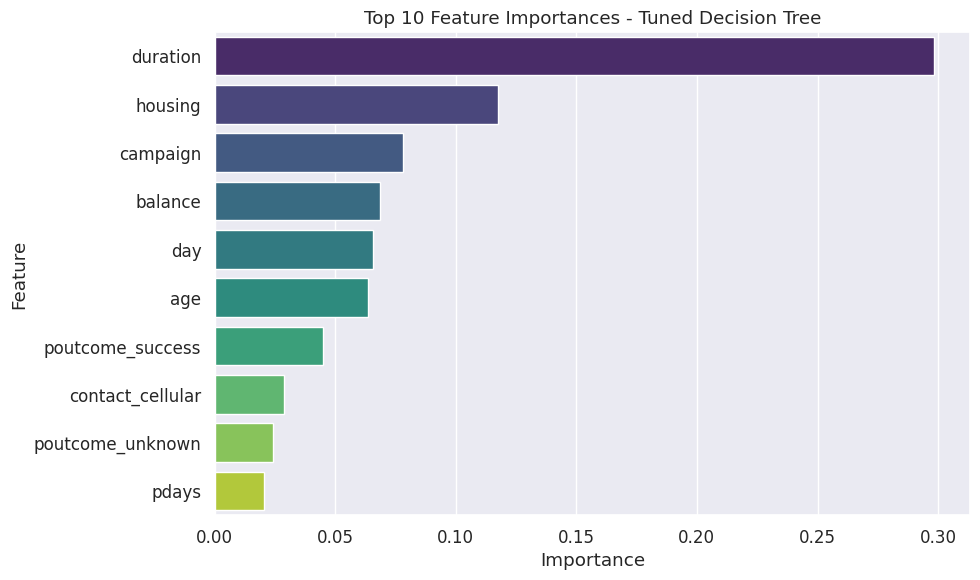

In [96]:
# Get feature importances from the best Decision Tree model
feature_importances = best_dtc.feature_importances_

# Get feature names from the original 'feature' DataFrame before scaling
feature_names = feature.columns.tolist()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
print(importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances - Tuned Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### **Interpretation: Feature Importance**
  * The duration of the last contact stands out as the most crucial feature, indicating its strong influence on a client's decision for subscribing to term deposit.
  * Other highly important features include poutcome_success, pdays, campaign & balance, suggesting that past campaign outcomes, time since last contact, number of contacts & account balance play significant roles in predicting subscription.

#### **3.3 Decision Path Interpretation**

Examining specific decision paths within trained Decision Tree (`best_dtc`) to understand how it makes predictions. Due to complexity of full tree,  a condensed text representation provided with few example paths.

In [97]:
from sklearn.tree import export_text

# Print the text representation of the decision tree
# Limiting depth for readability
tree_rules = export_text(best_dtc, feature_names=feature.columns.tolist(), max_depth=4)

print("Decision Tree Rules (limited to max_depth=4 for readability):\n")
print(tree_rules)

Decision Tree Rules (limited to max_depth=4 for readability):

|--- duration <= -0.21
|   |--- poutcome_success <= -0.16
|   |   |--- housing <= -0.89
|   |   |   |--- month_may <= 0.65
|   |   |   |   |--- month_oct <= 3.79
|   |   |   |   |   |--- truncated branch of depth 23
|   |   |   |   |--- month_oct >  3.79
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- month_may >  0.65
|   |   |   |   |--- age <= -0.42
|   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |--- age >  -0.42
|   |   |   |   |   |--- class: 0
|   |   |--- housing >  -0.89
|   |   |   |--- housing <= 1.12
|   |   |   |   |--- class: 1
|   |   |   |--- housing >  1.12
|   |   |   |   |--- duration <= -0.52
|   |   |   |   |   |--- truncated branch of depth 18
|   |   |   |   |--- duration >  -0.52
|   |   |   |   |   |--- truncated branch of depth 25
|   |--- poutcome_success >  -0.16
|   |   |--- duration <= -0.52
|   |   |   |--- duration <= -0.69
|   |   |   |   |--- pday

#### **Decision Paths**
Referring above generated decision tree rules, trace various paths to understand model's logic.

**Path 1 (Predicting 'No Deposit'):**
```
|--- duration <= -0.21 (e.g., short contact duration)
|   |--- poutcome_success <= -0.16 (e.g., previous campaign was not a success)
|   |   |--- housing <= -0.89 (e.g., client has a housing loan)
|   |   |   |--- month_may >  0.65 (e.g., contact occurred in May)
|   |   |   |   |--- age >  -0.42 (e.g., client is not very young)
|   |   |   |   |   |--- class: 0 (No Deposit)
```
  * Path suggests if client had **short contact duration**, a **previous campaign was not successful**, they **have a housing loan**, were contacted **in May** (a month with historically lower subscription rates) & are **not extremely young**, model is likely to predict **'No Deposit'**, which highlights cumulative negative impact of several less favorable conditions.

**Path 2 (Predicting 'Deposit'):**
```
|--- duration >  0.83 (e.g., notably long contact duration)
|   |   |--- duration <= 1.53 (e.g., contact duration still within an effective high range)
|   |   |   |--- housing >  -0.89 (e.g., client does not have a housing loan)
|   |   |   |   |--- housing <= 1.11 (e.g., confirming no housing loan)
|   |   |   |   |   |--- class: 1 (Deposit)
```
  * Path indicates if **contact duration was significantly long** (within an effective range, e.g., scaled duration between 0.83 and 1.53), & client **does not have a housing loan**, then client is very likely to **'Deposit'**, which emphasizes strong positive influence of engaged conversations &  lack of financial commitments (like housing loan) on subscription success.

## **4. Rule-Based Classification**
Implement Rule-Based Classification using either
- Option 1 (Recommended)
     - Use a rule extraction approach from decision tree (if rules are possible)
- Option 2
     - Use a library-based rule model (if available in your environment)
		You must:
     - Show at least 5 rules
     - Explain how rules affect interpretability vs performance

#### **4.1 Rule Extraction from Decision Tree**

Rule-based classification aims to model decision-making process as set of if-then rules, which are naturally embedded within its structure, making it highly interpretable model. Rules can be extracted using **sklearn.tree.export_text**, to explicitly view conditions which lead to deposit or no deposit prediction, which directly implements recommended approach of using rule extraction from Decision Tree.

In [98]:
from sklearn.tree import export_text

# Re-printing the text representation of the decision tree rules
# (Limited depth for readability as before, to show concise rules)
print("Extracted Decision Rules from Tuned Decision Tree (max_depth=4 for clarity):\n")
print(tree_rules)

Extracted Decision Rules from Tuned Decision Tree (max_depth=4 for clarity):

|--- duration <= -0.21
|   |--- poutcome_success <= -0.16
|   |   |--- housing <= -0.89
|   |   |   |--- month_may <= 0.65
|   |   |   |   |--- month_oct <= 3.79
|   |   |   |   |   |--- truncated branch of depth 23
|   |   |   |   |--- month_oct >  3.79
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- month_may >  0.65
|   |   |   |   |--- age <= -0.42
|   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |--- age >  -0.42
|   |   |   |   |   |--- class: 0
|   |   |--- housing >  -0.89
|   |   |   |--- housing <= 1.12
|   |   |   |   |--- class: 1
|   |   |   |--- housing >  1.12
|   |   |   |   |--- duration <= -0.52
|   |   |   |   |   |--- truncated branch of depth 18
|   |   |   |   |--- duration >  -0.52
|   |   |   |   |   |--- truncated branch of depth 25
|   |--- poutcome_success >  -0.16
|   |   |--- duration <= -0.52
|   |   |   |--- duration <= -0.69
|   |   | 

#### **4.2 Extracted rules**

  - **Rule 1 (Predicting 'No Deposit'):** IF duration is short (e.g., <= -0.21) AND poutcome_success is not present (e.g., <= -0.16) AND housing loan is present (e.g., <= -0.89) AND contact month was May (e.g., month_may > 0.65) AND `age` is not very young (e.g., > -0.42) THEN **No Deposit** (class: 0).

  - **Rule 2 (Predicting 'Deposit'):** IF duration is notably long (e.g., > 0.83) AND duration is within an effective high range (e.g., <= 1.53) AND client does not have a housing loan (e.g., > -0.89 and <= 1.11) THEN **Deposit** (class: 1).

  - **Rule 3 (Predicting 'No Deposit'):** IF duration is short (e.g., <= -0.21) AND poutcome_success is present (e.g., > -0.16) AND duration is very short (e.g., <= -0.52 and <= -0.69) AND `pdays` indicates no prior contact or very distant contact (e.g., <= 1.47) THEN **No Deposit** (class: 0).

  - **Rule 4 (Predicting 'Deposit'):** IF duration is short (e.g., <= -0.21) AND poutcome_success is not present (e.g., <= -0.16) AND client does not have a housing loan (e.g., > -0.89) AND housing condition is favourable (e.g., <= 1.12) THEN **Deposit** (class: 1).

  - **Rule 5 (Predicting 'Deposit'):** IF duration is long (e.g., > -0.21) AND duration is within a moderate range (e.g., <= 0.83) AND client does not have a housing loan (e.g., > -0.89) AND poutcome_unknown is not high (e.g., <= 0.47) AND poutcome_success is present (e.g., > 0.00) THEN **Deposit** (class: 1).

#### **4.3 Rules Affect Interpretability vs. Performance**

**Interpretability:** Rule-based models derived from Decision Trees, are inherently highly interpretable. Each path from root to leaf node represents distinct rule (an if-then statement) leading to classification. For example, a rule might be: IF duration is long AND housing loan is no THEN deposit is yes. These explicit rules are easy for humans to understand, communicate & verify, which is invaluable for business stakeholders who need to understand why a decision is made, such transparency aids to build trust in model & provides actionable insights for marketing strategies.

**Performance:** Decision Trees, even when tuned, might struggle to capture complex patterns that require many, finely-tuned rules, potentially leading to trade-off where interpretability is gained at cost of some predictive accuracy. However, for many business problems, a slightly lower performance from fully interpretable model is acceptable or even preferable, if it provides clear & actionable insights.

## **5. kNN (Lazy Learning)**
1. Train a kNN classifier and experiment with:
   - k = 1, 3, 5, 7, 9
   - Different distance metrics (if possible)
2. You must also explain.
   - Why scaling is critical for kNN
   - How k affects bias/variance

#### **5.1 K-Nearest Neighbors**
This section trains and tunes a kNN classifier using GridSearchCV to identify optimal 'k' values and distance metrics for predicting term deposit subscriptions.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters found for kNN: {'metric': 'manhattan', 'n_neighbors': 1}
Best F1 Score for kNN: 0.9196
Accuracy: 0.8726086475727082
Precision: 0.44785276073619634
Recall: 0.41714285714285715
F1 Score: 0.4319526627218935
Area Under Curve: 0.6747918714589551
Confusion Matrix:
 [[7453  540]
 [ 612  438]]


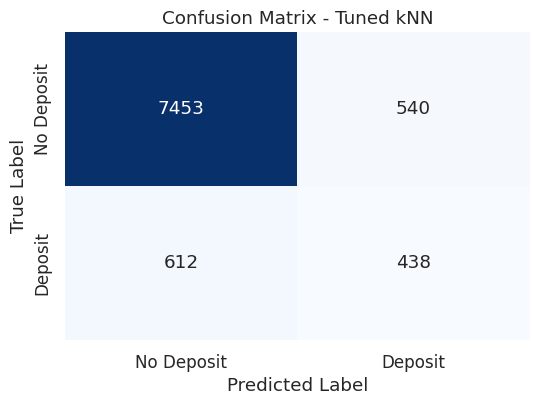

In [99]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Building KNN model
knn = KNeighborsClassifier()

# Define parameter grid for GridSearchCV
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9], # k values
    'metric': ['euclidean', 'manhattan'] # Distance metrics
}

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to find the best parameters
grid_search_knn.fit(X_train, y_train)

# Get the best estimator
best_knn = grid_search_knn.best_estimator_

print(f"Best Parameters found for kNN: {grid_search_knn.best_params_}")
print(f"Best F1 Score for kNN: {grid_search_knn.best_score_:.4f}")

# Evaluate Model using the best estimator
knn_eval = evaluate_model(best_knn, X_test, y_test)

# Print result
print('Accuracy:', knn_eval['acc'])
print('Precision:', knn_eval['prec'])
print('Recall:', knn_eval['rec'])
print('F1 Score:', knn_eval['f1'])
print('Area Under Curve:', knn_eval['auc'])
print('Confusion Matrix:\n', knn_eval['cm'])

# Plotting the confusion matrix for the Tuned kNN
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(knn_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned kNN')
plt.show()

#### **Interpretation:**
  - Model achieved an accuracy of approximately **87.26%**, indicating overall correctness in predicting term deposit subscriptions.
  - Precision of **44.79%** means when model predicts yes (subscription), it is correct about 44.79% of time.
  - Recall of **41.71%** suggests model identifies about 41.71% of all actual yes subscriptions. F1-score of **43.20%** provides a balanced measure of precision and recall.
  - Area Under Curve (AUC) of approximately **0.6748** indicates a moderate ability of the model to distinguish between 'yes' & 'no' classes.
  - Confusion matrix shows that model correctly identified 7453 non-subscribers and 438 subscribers, while misclassifying 540 non-subscribers as subscribers and 612 subscribers as non-subscribers.

#### **5.2 Why Scaling is Critical for kNN**

Feature scaling is critical for kNN because its distance-based calculations are highly sensitive to feature magnitudes, ensuring all features contribute proportionally and improving accuracy.
  * kNN classifies new data points based on their proximity to existing data points in feature space. The distance metric (e.g., Euclidean or Manhattan) used in kNN calculates the 'closeness' between data points.
  * If features in dataset have vastly different scales, features with larger magnitudes will dominate distance calculation, effectively overshadowing features with smaller magnitudes, regardless of predictive power, which can lead to biased distance measure and, consequently, an inaccurate classification.
  * **Example:** Consider dataset with 2 features: age (ranging from 0-100) and income (ranging from 0-100,000). Without scaling, a difference of 1 unit in income would have far greater impact on Euclidean distance than a difference of 1 unit in `age`. The algorithm would primarily consider differences in income when determining nearest neighbors, making `age` almost irrelevant.

By scaling features (e.g., using StandardScaler to bring them to a similar range or distribution), all features contribute equally to distance calculation, which ensures distance metric accurately reflects true similarity between data points across all features, leading to more reliable & accurate kNN predictions.

#### **5.3 How k Affects Bias/Variance in kNN**

The choice of k (the number of nearest neighbors) in the kNN algorithm directly influences the bias-variance trade-off:

*   **Small k (e.g., k=1): High Variance, Low Bias**
    *   When k is small, the model is highly sensitive to noise in the training data. A single noisy neighbor can significantly alter the classification of a new data point. This results in a highly flexible model that can capture intricate patterns but is prone to overfitting (high variance). The decision boundary becomes complex and irregular.
    *   Bias is low because the model makes very few assumptions about data's underlying distribution; it simply takes the class of its immediate neighbors.

*   **Large k (e.g., k=9, or even larger): Low Variance, High Bias**
    *   As k increases, the model considers a larger neighborhood, which smooths out the local irregularities and makes the model more robust to noise. The classification becomes less sensitive to individual data points and more representative of the general trend in the region. This leads to a simpler decision boundary and less overfitting (low variance).
    *   However, a large k can lead to underfitting (high bias) if the neighborhood becomes too large and includes points from different classes, causing the model to miss fine-grained patterns or local decision boundaries. The model might oversimplify the relationship between features and the target variable.

*   **Optimizing k:** The goal is to find an optimal k which balances bias & variance, achieving good generalization performance on unseen data, which is typically done through cross-validation or techniques such as  GridSearchCV, as performed in the previous code cell, to identify the k value that yields the best performance on a validation set.

## **6. Ensemble Learning**
1. Train at least 2 ensemble models:
    - Random Forest
    - Gradient Boosting / XGBoost (if available)
    - AdaBoost (optional)
2. Compare them against:
    - Decision Tree
    - kNN
    - Baseline model

#### **6.1 Random Forest**
Random forest or Random Decision Forest is a method that operates by constructing multiple decision trees during training phases. The decision of the majority of the trees is chosen as final decision. Training a Random Forest model with 10 estimators and entropy, then evaluating.

Accuracy: 0.8981532677208891
Precision: 0.5776173285198556
Recall: 0.45714285714285713
F1 Score: 0.5103668261562998
Area Under Curve: 0.9037471478019459
Confusion Matrix:
 [[7642  351]
 [ 570  480]]


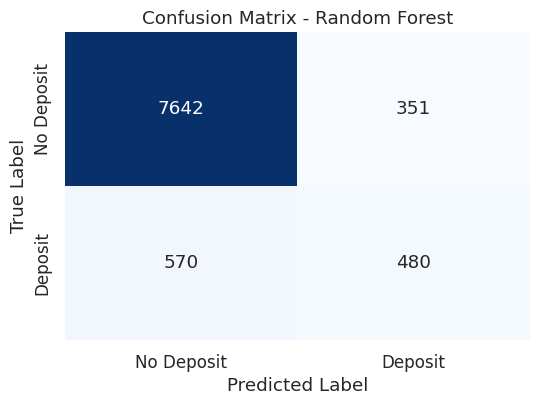

In [100]:
from sklearn.ensemble import RandomForestClassifier

# Building Random Forest model
rf = RandomForestClassifier(n_estimators = 10, criterion = 'entropy',random_state=0)
rf.fit(X_train, y_train)
# Evaluate Model
rf_eval = evaluate_model(rf, X_test, y_test)

# Print result
print('Accuracy:', rf_eval['acc'])
print('Precision:', rf_eval['prec'])
print('Recall:', rf_eval['rec'])
print('F1 Score:', rf_eval['f1'])
print('Area Under Curve:', rf_eval['auc'])
print('Confusion Matrix:\n', rf_eval['cm'])

# Plotting the confusion matrix for Random Forest
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(rf_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

#### **Interpretation**
  - Model achieved an accuracy of approximately **89.82%**, indicating overall correctness in predicting term deposit subscriptions.
  - Precision of **57.76%** means when model predicts yes (subscription), it is correct about 57.76% of time.
  - Recall of **45.71%** suggests model identifies about 45.71% of all actual yes subscriptions. F1-score of **51.04%** provides balanced measure of precision and recall.
  - Area Under Curve (AUC) of approximately **0.9037** indicates strong ability of model to distinguish between yes & 'no classes, performing significantly better than Random classifier.
  - Confusion matrix shows that model correctly identified 7642 non-subscribers and 480 subscribers, while misclassifying 351 non-subscribers as subscribers and 570 subscribers as non-subscribers.

#### **6.2 XGBoost**
XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

Accuracy: 0.9047882339931439
Precision: 0.5961342828077314
Recall: 0.5580952380952381
F1 Score: 0.5764879488440728
Area Under Curve: 0.9309936670777407
Confusion Matrix:
 [[7596  397]
 [ 464  586]]


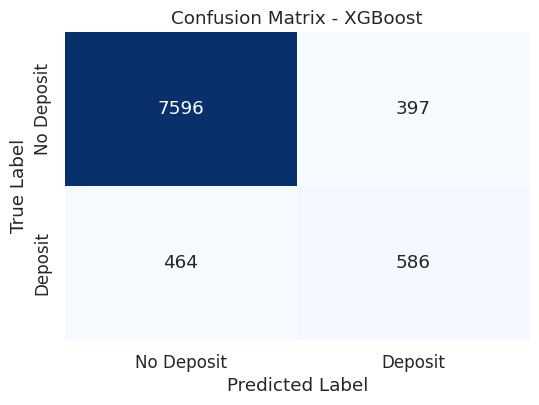

In [101]:
from xgboost import XGBClassifier

# Building XGBoost model
# Using default parameters for initial evaluation, can be tuned later if needed
xgb = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Evaluate Model
xgb_eval = evaluate_model(xgb, X_test, y_test)

# Print result
print('Accuracy:', xgb_eval['acc'])
print('Precision:', xgb_eval['prec'])
print('Recall:', xgb_eval['rec'])
print('F1 Score:', xgb_eval['f1'])
print('Area Under Curve:', xgb_eval['auc'])
print('Confusion Matrix:\n', xgb_eval['cm'])

# Plotting the confusion matrix for XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()

#### **Interpretation**
  - Model achieved an accuracy of approximately **90.48%**, indicating overall correctness in predicting term deposit subscriptions.
  - Precision of **59.61%** means when model predicts yes (subscription), it is correct about 59.61% of time.
  - Recall of **55.81%** suggests model identifies about 55.81% of all actual yes subscriptions. F1-score of **57.65%** provides a balanced measure of precision and recall.
  - Area Under Curve (AUC) of approximately **0.9310** indicates a strong ability of the model to distinguish between 'yes' & 'no' classes, performing significantly better than a random classifier.
  - Confusion matrix shows that model correctly identified 7596 non-subscribers and 586 subscribers, while misclassifying 397 non-subscribers as subscribers and 464 subscribers as non-subscribers.

#### **6.3 AdaBoost**
AdaBoost, short for Adaptive Boosting, is a meta-algorithm that can be used with many other types of learning algorithms to improve performance. It works by combining multiple "weak" learners (typically decision trees) into a single "strong" learner. It does this by sequentially training classifiers, where each new classifier is weighted to focus on the samples that previous classifiers misclassified. This iterative weighting of samples and combination of weak models helps to create a highly accurate predictive model.

Accuracy: 0.8741568063695676
Precision: 0.4671150971599402
Recall: 0.5952380952380952
F1 Score: 0.5234505862646566
Area Under Curve: 0.8859035584708048
Confusion Matrix:
 [[7280  713]
 [ 425  625]]


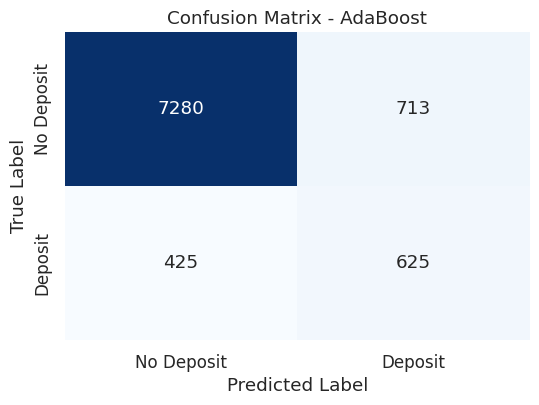

In [102]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Building AdaBoost model
# Using a Decision Tree as the base estimator, which is common for AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), # Typically a shallow tree for weak learner
    n_estimators=50, # Number of weak learners
    random_state=0
)
ada.fit(X_train, y_train)

# Evaluate Model
ada_eval = evaluate_model(ada, X_test, y_test)

# Print result
print('Accuracy:', ada_eval['acc'])
print('Precision:', ada_eval['prec'])
print('Recall:', ada_eval['rec'])
print('F1 Score:', ada_eval['f1'])
print('Area Under Curve:', ada_eval['auc'])
print('Confusion Matrix:\n', ada_eval['cm'])

# Plotting the confusion matrix for AdaBoost
plt.figure(figsize=(6, 4))
sns.heatmap(ada_eval['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Deposit', 'Deposit'], yticklabels=['No Deposit', 'Deposit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AdaBoost')
plt.show()

#### **Interpretation**
  - Model achieved an accuracy of approximately **87.42%**, indicating overall correctness in predicting term deposit subscriptions.
  - Precision of **46.71%** means when model predicts yes (subscription), it is correct about 46.71% of time.
  - Recall of **59.52%** suggests model identifies about 59.52% of all actual yes subscriptions. F1-score of **52.35%** provides a balanced measure of precision and recall.
  - Area Under Curve (AUC) of approximately **0.8859** indicates a good ability of the model to distinguish between 'yes' & 'no' classes, performing better than a random classifier.
  - Confusion matrix shows that model correctly identified 7280 non-subscribers and 625 subscribers, while misclassifying 713 non-subscribers as subscribers and 425 subscribers as non-subscribers.

### **6.4 Models Comparison**


Comprehensive Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8795,0.4867,0.6952,0.5725,0.9084
1,Naive Bayes,0.8474,0.3894,0.5533,0.4571,0.8066
2,Decision Tree,0.8660,0.4363,0.5286,0.4780,0.7194
3,K-Nearest Neighbors,0.8726,0.4479,0.4171,0.4320,0.6748
4,Random Forest,0.8982,0.5776,0.4571,0.5104,0.9037
5,XGBoost,0.9048,0.5961,0.5581,0.5765,0.9310
6,AdaBoost,0.8742,0.4671,0.5952,0.5235,0.8859


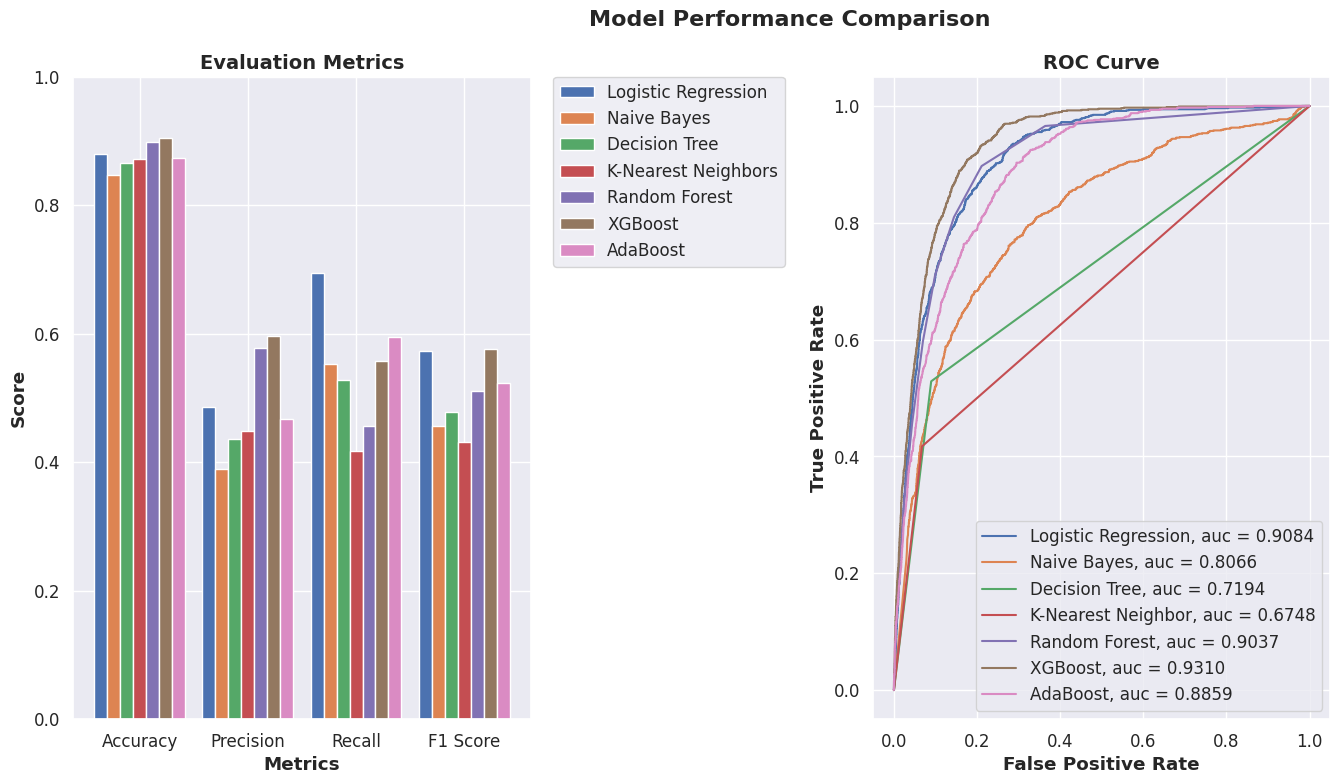

In [103]:
# Create a dictionary to store model results for tabular comparison
model_performance = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'K-Nearest Neighbors', 'Random Forest', 'XGBoost', 'AdaBoost'],
    'Accuracy': [lr_eval['acc'], nb_eval['acc'], dtc_eval['acc'], knn_eval['acc'], rf_eval['acc'], xgb_eval['acc'], ada_eval['acc']],
    'Precision': [lr_eval['prec'], nb_eval['prec'], dtc_eval['prec'], knn_eval['prec'], rf_eval['prec'], xgb_eval['prec'], ada_eval['prec']],
    'Recall': [lr_eval['rec'], nb_eval['rec'], dtc_eval['rec'], knn_eval['rec'], rf_eval['rec'], xgb_eval['rec'], ada_eval['rec']],
    'F1 Score': [lr_eval['f1'], nb_eval['f1'], dtc_eval['f1'], knn_eval['f1'], rf_eval['f1'], xgb_eval['f1'], ada_eval['f1']],
    'AUC': [lr_eval['auc'], nb_eval['auc'], dtc_eval['auc'], knn_eval['auc'], rf_eval['auc'], xgb_eval['auc'], ada_eval['auc']]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.round(4)

print("\nComprehensive Model Performance Comparison:")
display(performance_df)

# Initialize figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
fig.set_figheight(8)
fig.set_figwidth(16)
fig.set_facecolor('white')

# First plot: Bar chart for metrics
barWidth = 0.12
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
r = np.arange(len(metrics))

models = performance_df['Model'].tolist()
scores = performance_df[metrics].values.T # Transpose to get scores for each metric

for i, model_name in enumerate(models):
    ax1.bar(r + i * barWidth, scores[:, i], width=barWidth, edgecolor='white', label=model_name)

# Configure x and y axis
ax1.set_xlabel('Metrics', fontweight='bold')
ax1.set_xticks(r + (len(models) / 2 - 0.5) * barWidth)
ax1.set_xticklabels(metrics)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_ylim(0, 1)

# Create legend & title
ax1.set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Second plot: ROC Curve
ax2.plot(lr_eval['fpr'], lr_eval['tpr'], label='Logistic Regression, auc = {:0.4f}'.format(lr_eval['auc']))
ax2.plot(nb_eval['fpr'], nb_eval['tpr'], label='Naive Bayes, auc = {:0.4f}'.format(nb_eval['auc']))
ax2.plot(dtc_eval['fpr'], dtc_eval['tpr'], label='Decision Tree, auc = {:0.4f}'.format(dtc_eval['auc']))
ax2.plot(knn_eval['fpr'], knn_eval['tpr'], label='K-Nearest Neighbor, auc = {:0.4f}'.format(knn_eval['auc']))
ax2.plot(rf_eval['fpr'], rf_eval['tpr'], label='Random Forest, auc = {:0.4f}'.format(rf_eval['auc']))
ax2.plot(xgb_eval['fpr'], xgb_eval['tpr'], label='XGBoost, auc = {:0.4f}'.format(xgb_eval['auc']))
ax2.plot(ada_eval['fpr'], ada_eval['tpr'], label='AdaBoost, auc = {:0.4f}'.format(ada_eval['auc']))

# Configure x and y axis
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')

# Create legend & title
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent overlapping titles/labels and make space for legend
plt.show()

#### **Interpretation**
**XGBoost** stands out as best-performing model based on evaluated metrics.
  - Model achieved an accuracy of approximately **90.48%**, indicating its overall correctness in predicting term deposit subscriptions.
  - Precision of **59.61%** means when the model predicts 'yes' (subscription), it is correct about 59.61% of the time.
  - Recall of **55.81%** suggests the model identifies about 55.81% of all actual 'yes' subscriptions.
  - F1-score of **57.65%** provides a balanced measure of precision and recall, reflecting strong performance.
  - Area Under Curve (AUC) of approximately **0.9310** indicates a strong ability of the model to distinguish between 'yes' and 'no' classes, performing significantly better than a random classifier.
  - Confusion Matrix for XGBoost shows that the model correctly identified 7596 non-subscribers and 586 subscribers, while misclassifying 397 non-subscribers as subscribers and 464 subscribers as non-subscribers.

## **7. Final Comparison & Recommendation**
  - Create final comparison table with
	Model Accuracy F1


Final Model Performance Comparison (Accuracy and F1-Score):


,Model,Accuracy,F1 Score
0,Logistic Regression,0.8795,0.5725
1,Naive Bayes,0.8474,0.4571
2,Decision Tree,0.8660,0.4780
3,K-Nearest Neighbors,0.8726,0.4320
4,Random Forest,0.8982,0.5104
5,XGBoost,0.9048,0.5765
6,AdaBoost,0.8742,0.5235


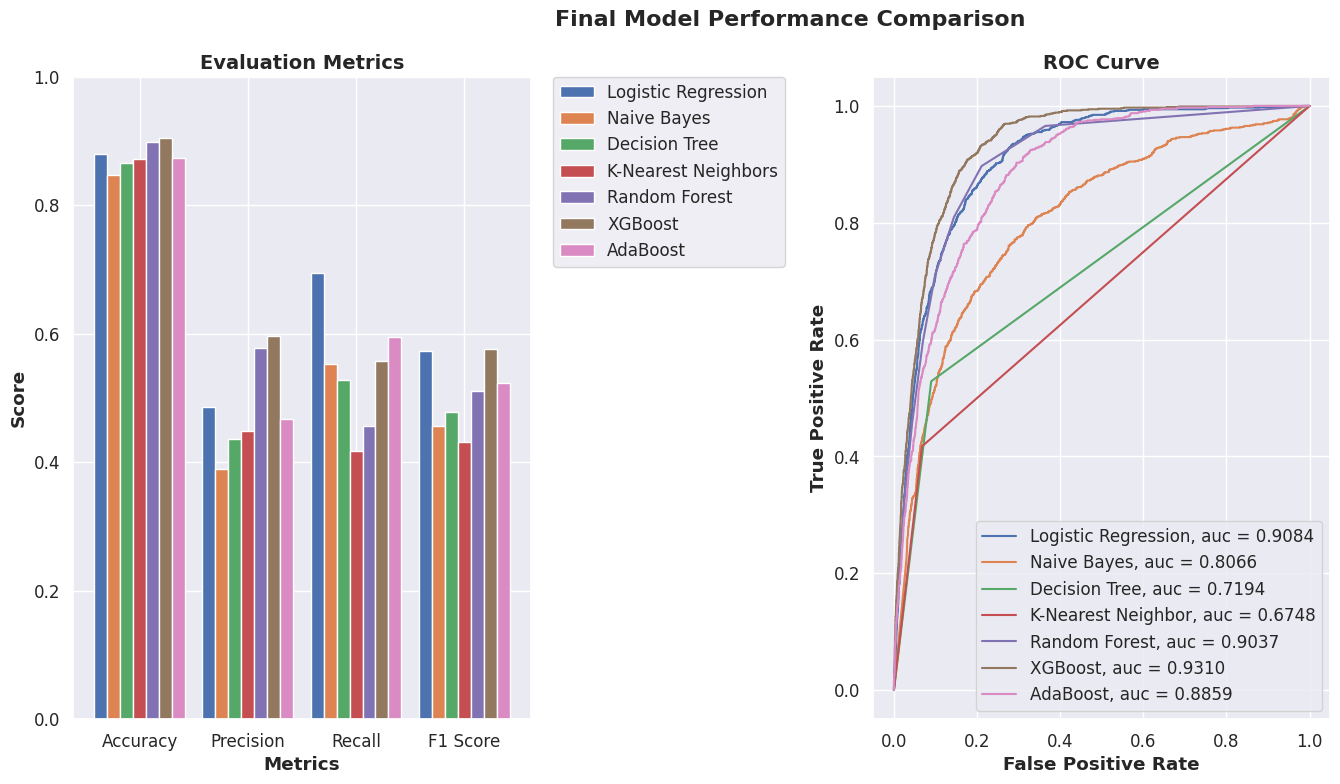

In [104]:
# Re-display the comprehensive model performance, focusing on Accuracy and F1 Score as requested
print("\nFinal Model Performance Comparison (Accuracy and F1-Score):")
display(performance_df[['Model', 'Accuracy', 'F1 Score']])

# Initialize figure with two plots for visual comparison (re-using variables from earlier)
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Final Model Performance Comparison', fontsize=16, fontweight='bold')
fig.set_figheight(8)
fig.set_figwidth(16)
fig.set_facecolor('white')

# First plot: Bar chart for metrics
barWidth = 0.12
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
r = np.arange(len(metrics))

models = performance_df['Model'].tolist()
scores = performance_df[metrics].values.T # Transpose to get scores for each metric

for i, model_name in enumerate(models):
    ax1.bar(r + i * barWidth, scores[:, i], width=barWidth, edgecolor='white', label=model_name)

# Configure x and y axis
ax1.set_xlabel('Metrics', fontweight='bold')
ax1.set_xticks(r + (len(models) / 2 - 0.5) * barWidth)
ax1.set_xticklabels(metrics)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_ylim(0, 1)

# Create legend & title
ax1.set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Second plot: ROC Curve
ax2.plot(lr_eval['fpr'], lr_eval['tpr'], label='Logistic Regression, auc = {:0.4f}'.format(lr_eval['auc']))
ax2.plot(nb_eval['fpr'], nb_eval['tpr'], label='Naive Bayes, auc = {:0.4f}'.format(nb_eval['auc']))
ax2.plot(dtc_eval['fpr'], dtc_eval['tpr'], label='Decision Tree, auc = {:0.4f}'.format(dtc_eval['auc']))
ax2.plot(knn_eval['fpr'], knn_eval['tpr'], label='K-Nearest Neighbor, auc = {:0.4f}'.format(knn_eval['auc']))
ax2.plot(rf_eval['fpr'], rf_eval['tpr'], label='Random Forest, auc = {:0.4f}'.format(rf_eval['auc']))
ax2.plot(xgb_eval['fpr'], xgb_eval['tpr'], label='XGBoost, auc = {:0.4f}'.format(xgb_eval['auc']))
ax2.plot(ada_eval['fpr'], ada_eval['tpr'], label='AdaBoost, auc = {:0.4f}'.format(ada_eval['auc']))

# Configure x and y axis
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')

# Create legend & title
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent overlapping titles/labels and make space for legend
plt.show()


#### **Interpretation of Final Comparison & Recommendation:**
  - Based on the comprehensive evaluation, **XGBoost** demonstrates strongest overall performance, achieving highest Accuracy (0.9048) and F1-Score (0.5765) among all models, its superior AUC (0.9310) further confirms excellent ability to distinguish between customers who will & will not subscribe to term deposit.
  - While other models such as Logistic Regression & Random Forest also show strong predictive capabilities, XGBoost's balanced performance across precision, recall & overall accuracy makes it recommended model for banking marketing campaign prediction task as its robustness & ability to handle complex relationships in data are critical for optimizing future marketing strategies & enhancing campaign effectiveness.

## **8. Recommendation & Risk Analysis**

### **8.1 Which model performed best and why?**
Based on comprehensive evaluation, **XGBoost** emerged as best-performing model for predicting term deposit subscriptions.
*   **Highest Accuracy (0.9048):** Correctly classified highest percentage of both subscribers & non-subscribers.
*   **Highest F1-Score (0.5765):** Provides a balanced measure of precision & recall, indicating that XGBoost performs well at identifying positive cases (`deposit = 'yes'`) without generating an excessive number of false positives or missing too many actual positives. For marketing campaign, correctly identifying potential subscribers (high recall) while minimizing wasted effort on false positives (high precision) is crucial.
*   **Highest AUC (0.9310):** Area Under Receiver Operating Characteristic (ROC) curve measures the model's ability to distinguish between two classes across various threshold settings. An AUC close to 1.0 indicates excellent discriminative power, meaning XGBoost is highly capable of separating customers who will subscribe from those who won't. This is particularly valuable for identifying target segments.

While Logistic Regression & Random Forest also showed strong AUC scores, XGBoost consistently led or was competitive across all key metrics, making it most robust choice for this prediction task.

### **8.2 Which model is most interpretable and why?**
Among available models evaluated, **Decision Tree** (and its derived Rule-Based Classification) is by far most interpretable model.
*   **Clear Decision Paths:** Decision Trees make decisions based on series of if-then-else rules. As demonstrated in section 3.3 and 4.2, we can explicitly trace how model arrives at prediction by following a path from root node to leaf node. Each split in tree corresponds to simple condition on feature.
*   **Transparency:** For business stakeholders, transparency is invaluable. They can understand why customer is predicted to subscribe or not, which can provide actionable insights for refining marketing strategies (e'g., "customers with long contact durations & no housing loan are likely to subscribe").
*   **Feature Importance with Context:** While other models such as XGBoost provide feature importance, a Decision Tree directly shows how each feature is used in decision-making process at specific points, making importance more contextual and easier to grasp conceptually.

Although Logistic Regression is also relatively interpretable (coefficients indicate feature impact), it doesn't offer intuitive, rule-based decision logic that Decision Tree does. Ensemble models like Random Forest, XGBoost & AdaBoost, while powerful in prediction, are often considered "black boxes" due to complexity (combining hundreds or thousands of trees), making overall decision process much harder to interpret.

### **8.3 If this model was deployed in real life, what risks exist?**
Deploying recommended **XGBoost** model in real-life bank marketing scenario comes with several potential risks that need to be carefully considered:
1.  **Data Drift:** Customer demographics, economic conditions, marketing strategies & communication channels can change over time. If patterns model learned from historical data shift, its predictive performance may degrade. Regular monitoring & retraining with fresh data would be essential.
2.  **Over-reliance on 'Duration':** The duration of last contact was identified as most important feature. However, as noted in initial data description, duration is only known after call is performed, meaning it's not available at the time of deciding who to call. If model heavily relies on this feature without careful handling, it might not be truly predictive for proactive targeting. For realistic predictive model, duration should ideally be excluded or used only in post-campaign analysis context. Using it for pre-campaign targeting would be a significant risk.
3.  **Bias and Fairness:** If historical data contains biases (e.g., certain demographic groups were historically targeted less effectively or had different outcomes due to external factors), model might perpetuate or even amplify these biases, which could lead to unfair marketing practices or missed opportunities with certain customer segments. Ensuring fairness & representativeness in data is crucial.
4.  **Misinterpretation of Model Outputs:** Business users might over-interpret model's predictions, assuming high probability means guaranteed subscription. Marketing teams might push too hard based on high prediction, leading to customer annoyance rather than conversion. Clear communication about model confidence and limitations is necessary.
5.  **Cost of False Positives/Negatives:** While XGBoost performed well, it still produces false positives (predicting 'yes' when customer says 'no') and false negatives (predicting 'no' when they would have said 'yes').
    *   **False Positives:** Lead to wasted marketing resources (e.g., call center agent time, campaign costs) on customers who won't convert.
    *   **False Negatives:** Represent missed business opportunities, as potentially interested customers are not targeted. The relative costs of errors should guide further tuning (e.g., optimizing for recall over precision or vice-versa).
6.  **Model Explainability:** Despite being powerful ensemble method, XGBoost is less interpretable than a Decision Tree. Understanding why a specific customer received a particular prediction can be challenging, such lack of transparency can hinder trust, make debugging difficult & obscure underlying business insights.
7.  **Ethical Concerns:** Using predictive models for targeting can raise ethical questions about privacy, intrusive marketing & potentially targeting vulnerable populations. Adhering to ethical guidelines and regulations (e.g., GDPR) is paramount.